# ISDS 7075 Final Project
## Medical Appointment No-Show Prediction
## Group 7
### Brent Buchtel, Cameron Landress, Shannon O'Kelly

This notebook combines **Part 1** (exploration and cleaning) with **Parts 2 and 3** (modeling, concurrent flags, deployment).

**Flow**
1. Load raw data and explore
2. Split once (stratified 80/20)
3. Clean and engineer once with a shared function
4. Model iterations A, B, and C
5. One production score with three clinical thresholds
6. Recommendation, calibration, monitoring, and limits


## Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay
)

%matplotlib inline
sns.set()


## Load the data

We load the original appointment file once. All later steps build from this frame.


In [2]:
df = pd.read_csv('appointment_no_shows.csv')
print('Raw shape:', df.shape)
print('Columns:', list(df.columns))
df.head()


Raw shape: (110527, 14)
Columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Check Data Type

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


## Summary Description

In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172615e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173180e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439170e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999820e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


## Total Appointments and No Show Rate

In [5]:

# Record Count and No Show Rate
print(f'Total number of appointments: {len(df):,}')
print(f'Number of columns: {df.shape[1]}')
print()
print('No-show value counts:')
print(df['No-show'].value_counts())
print()
print('No-show proportions:')
print(df['No-show'].value_counts(normalize=True).round(4))
print()
print(f'Percentage of No-show = Yes: {100 * (df["No-show"] == "Yes").mean():.2f}%')

Total number of appointments: 110,527
Number of columns: 14

No-show value counts:
No-show
No     88208
Yes    22319
Name: count, dtype: int64

No-show proportions:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64

Percentage of No-show = Yes: 20.19%


**Take-away:** The dataset contains tens of thousands of appointments and roughly one in five patients does not show up. There are no missing values in any column.

## Visual Analysis With Seaborn

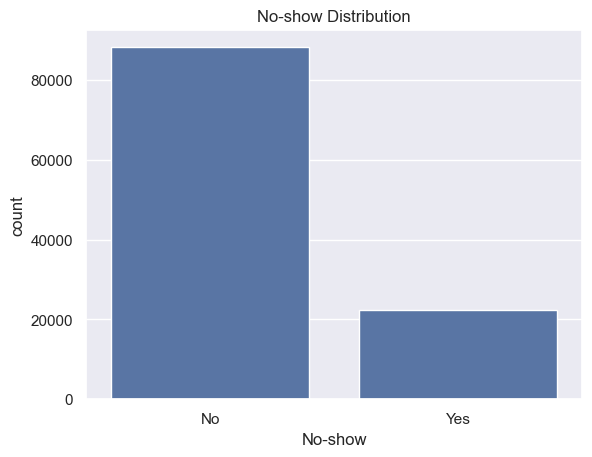

In [6]:
sns.countplot(x='No-show', data=df)
plt.title('No-show Distribution')
plt.show()

**Take-away:** Most patients show up for the appointments.

### Explore Gender and No-show

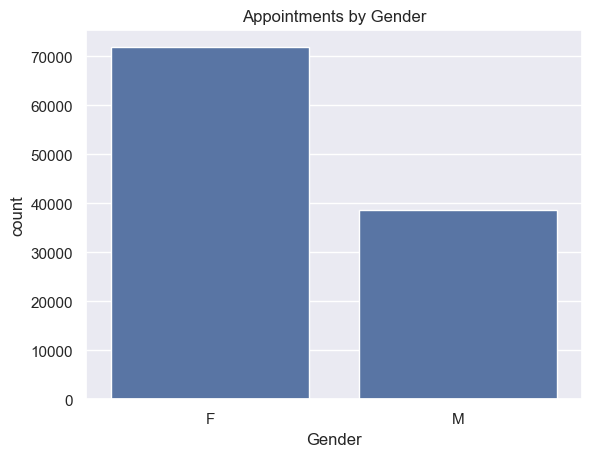

In [7]:
sns.countplot(x='Gender', data=df)
plt.title('Appointments by Gender')
plt.show()

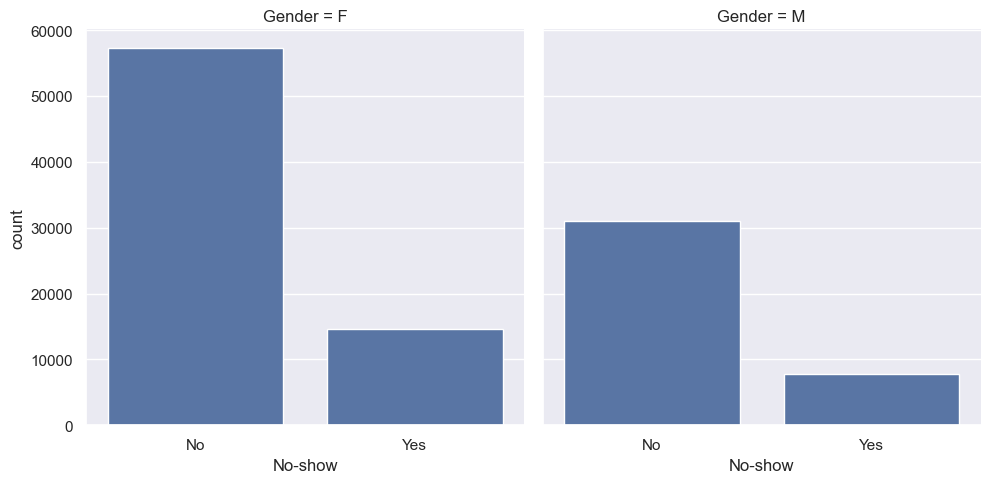

In [8]:
sns.catplot(x='No-show', col='Gender', kind='count', data=df)
plt.show()

In [9]:
# Exact no-show rates by gender
print('No-show rate: Female:')
print(df[df.Gender == 'F']['No-show'].value_counts(normalize=True).round(4))
print()
print('No-show rate: Male:')
print(df[df.Gender == 'M']['No-show'].value_counts(normalize=True).round(4))

No-show rate: Female:
No-show
No     0.7969
Yes    0.2031
Name: proportion, dtype: float64

No-show rate: Male:
No-show
No     0.8003
Yes    0.1997
Name: proportion, dtype: float64


**Take-away:** Gender differences in no show rate are small.

### Explore SMS_received

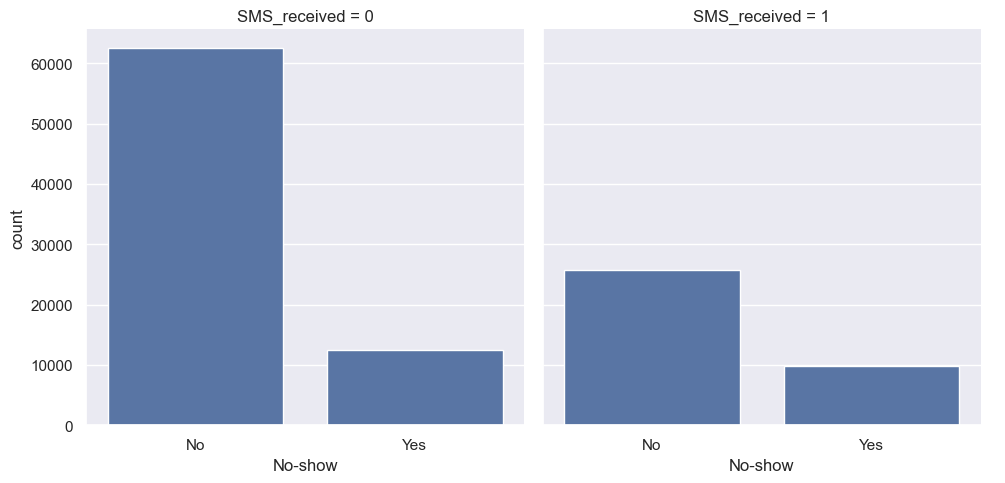

In [10]:
sns.catplot(x='No-show', col='SMS_received', kind='count', data=df)
plt.show()

In [11]:
print('No-show rate when SMS_received = 0:')
print(df[df.SMS_received == 0]['No-show'].value_counts(normalize=True).round(4))
print()
print('No-show rate when SMS_received = 1:')
print(df[df.SMS_received == 1]['No-show'].value_counts(normalize=True).round(4))

No-show rate when SMS_received = 0:
No-show
No     0.833
Yes    0.167
Name: proportion, dtype: float64

No-show rate when SMS_received = 1:
No-show
No     0.7243
Yes    0.2757
Name: proportion, dtype: float64


**Take-away:** Surprisingly patients who received an SMS actually have a higher no show rate.

### Exploring Other Binary Features

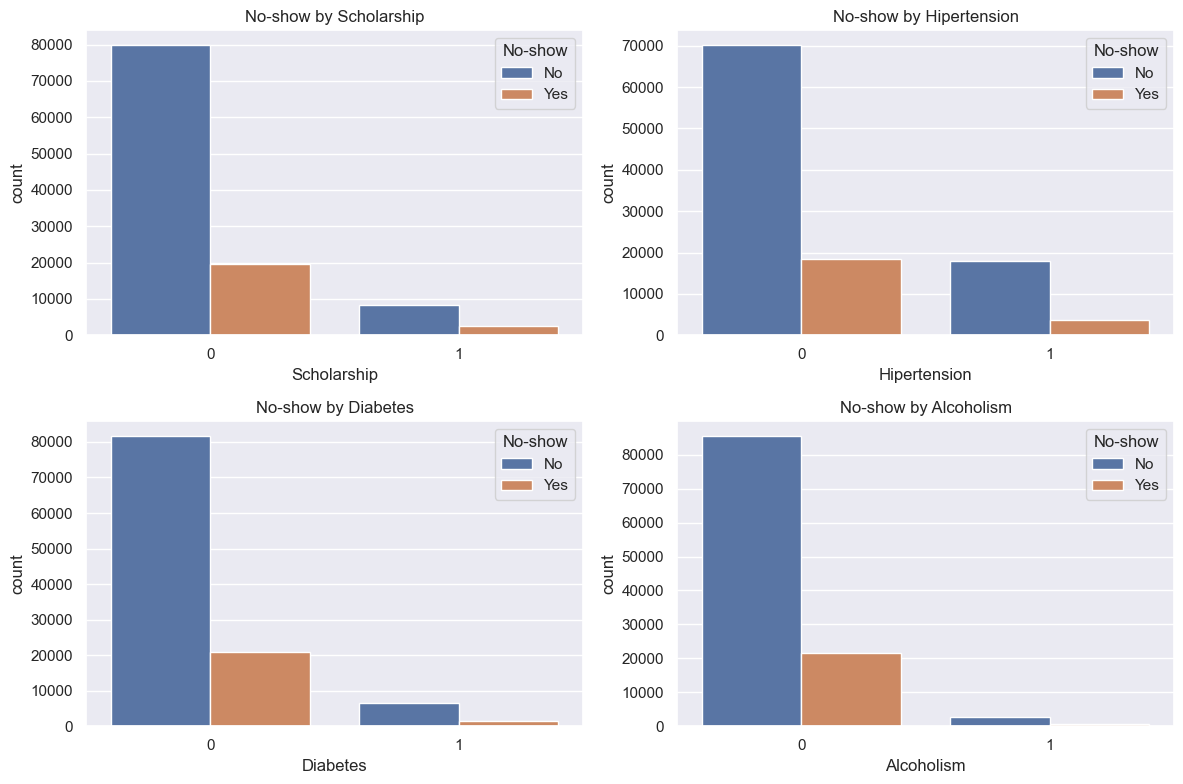

In [12]:
binary_cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='No-show', data=df, ax=axes[i])
    axes[i].set_title(f'No-show by {col}')

plt.tight_layout()
plt.show()

In [13]:
for col in binary_cols:
    print(f'{col} ')
    print(pd.crosstab(df[col], df['No-show'], normalize='index').round(4))
    print()

Scholarship 
No-show          No     Yes
Scholarship                
0            0.8019  0.1981
1            0.7626  0.2374

Hipertension 
No-show          No    Yes
Hipertension              
0             0.791  0.209
1             0.827  0.173

Diabetes 
No-show       No     Yes
Diabetes                
0         0.7964  0.2036
1         0.8200  0.1800

Alcoholism 
No-show         No     Yes
Alcoholism                
0           0.7981  0.2019
1           0.7985  0.2015



**Take-away:** These features show modest differences in no show rate. They are still worth keeping for modelling.

### Explore Age

In [14]:
print(df['Age'].describe())
print()
print(f'Records with Age < 0 : {(df["Age"] < 0).sum()}')
print(f'Records with Age > 100: {(df["Age"] > 100).sum()}')

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

Records with Age < 0 : 1
Records with Age > 100: 7


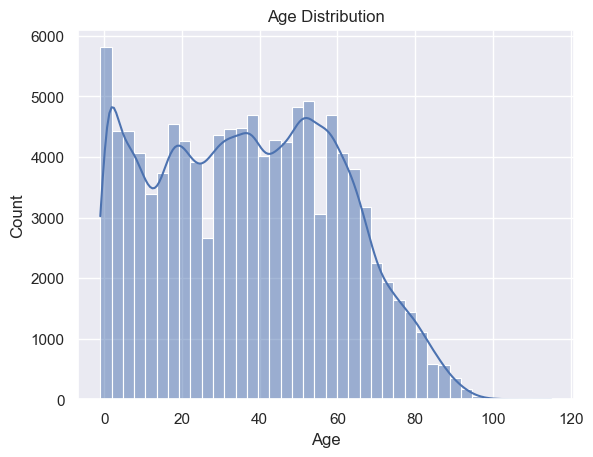

In [15]:
sns.histplot(df['Age'], bins=40, kde=True)
plt.title('Age Distribution')
plt.show()

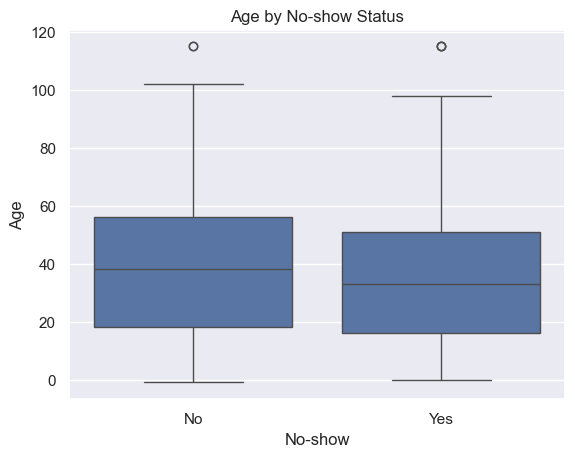

In [16]:
sns.boxplot(x='No-show', y='Age', data=df)
plt.title('Age by No-show Status')
plt.show()

**Take-away:** There are a few invalid ages (negative or > 100). Younger patients appear slightly more likely to no show. We will clean the invalid ages during wrangling.

### Explore Waiting Time

AppointmentDay does not contain time of day specif information while ScheduledDay has a full timestamp. This caused an issue when exploring the how wait time effected no shows. Negative wait times were presenting do to the discrepancy. To address this time of day was removed. Wait time was then binned to limit the number of features.

In [17]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Raw difference (can be negative)
df['WaitDays_raw'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

print('Raw WaitDays statistics:')
print(df['WaitDays_raw'].describe())
print(f'\nNumber of negative raw wait days: {(df["WaitDays_raw"] < 0).sum()}')

Raw WaitDays statistics:
count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: WaitDays_raw, dtype: float64

Number of negative raw wait days: 38568


In [18]:
# Cleaned version: difference in calendar days
df['ScheduledDate'] = df['ScheduledDay'].dt.floor('D')
df['AppointmentDate'] = df['AppointmentDay'].dt.floor('D')
df['WaitDays'] = (df['AppointmentDate'] - df['ScheduledDate']).dt.days

print('Cleaned WaitDays statistics:')
print(df['WaitDays'].describe())
print(f'\nNumber of negative WaitDays after cleaning: {(df["WaitDays"] < 0).sum()}')

Cleaned WaitDays statistics:
count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitDays, dtype: float64

Number of negative WaitDays after cleaning: 5


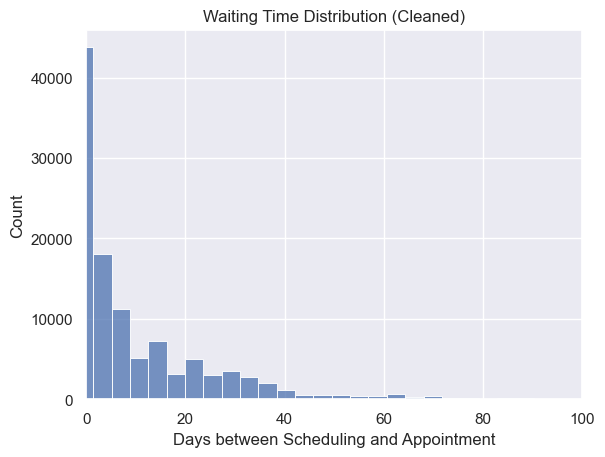

In [19]:
sns.histplot(df['WaitDays'], bins=50)
plt.title('Waiting Time Distribution (Cleaned)')
plt.xlabel('Days between Scheduling and Appointment')
plt.xlim(0, 100)
plt.show()

WaitBin
Same day      0.0465
1-2 days      0.2274
3-7 days      0.2498
8-14 days     0.3047
15-30 days    0.3259
30+ days      0.3300
Name: No-show, dtype: float64


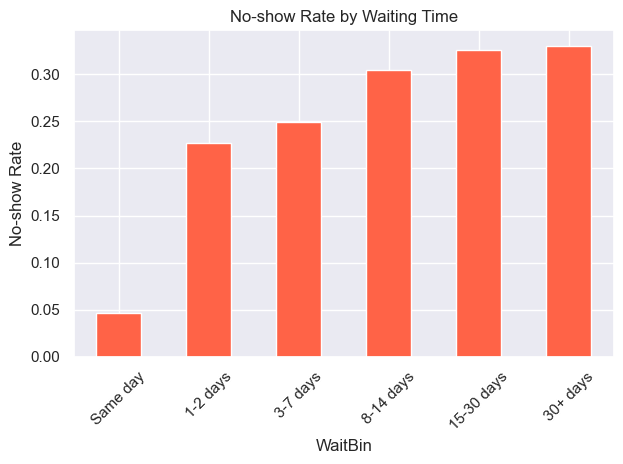

In [20]:
# No-show rate by waiting-time bins
df['WaitBin'] = pd.cut(df['WaitDays'],
                       bins=[-1, 0, 2, 7, 14, 30, 200],
                       labels=['Same day', '1-2 days', '3-7 days',
                               '8-14 days', '15-30 days', '30+ days'])

wait_rate = df.groupby('WaitBin', observed=True)['No-show'].apply(
    lambda x: (x == 'Yes').mean()
)
print(wait_rate.round(4))

wait_rate.plot(kind='bar', color='tomato')
plt.title('No-show Rate by Waiting Time')
plt.ylabel('No-show Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Take-away:** Same day appointments have a very low no show rate. Longer waits are associated with higher no show rates. Waiting time is likely one of the strongest predictors.

### Explore Neighborhood

In [21]:
print(f'Number of unique neighborhoods: {df["Neighbourhood"].nunique()}')
print()
print('Top 10 neighborhoods by volume:')
print(df['Neighbourhood'].value_counts().head(10))

Number of unique neighborhoods: 81

Top 10 neighborhoods by volume:
Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64


In [22]:
# Neighbourhood no show rates

neigh_stats = (
    df.groupby('Neighbourhood')
      .agg(
          appointments=('No-show', 'size'),
          no_shows=('No-show', lambda x: (x == 'Yes').sum()),
          no_show_rate=('No-show', lambda x: (x == 'Yes').mean())
      )
      .query('appointments >= 200')   # keep only neighbourhoods with at least 200 appointments
      .sort_values('no_show_rate', ascending=False)
)

print('Highest no-show rate neighbourhoods (n ≥ 200):')
print(neigh_stats.head(15).round(4))

print('\nLowest no-show rate neighbourhoods (n ≥ 200):')
print(neigh_stats.tail(10).round(4))

Highest no-show rate neighbourhoods (n ≥ 200):
                   appointments  no_shows  no_show_rate
Neighbourhood                                          
SANTOS DUMONT              1276       369        0.2892
SANTA CECÍLIA               448       123        0.2746
SANTA CLARA                 506       134        0.2648
ITARARÉ                    3514       923        0.2627
JESUS DE NAZARETH          2853       696        0.2440
ILHA DO PRÍNCIPE           2266       532        0.2348
CARATOÍRA                  2565       591        0.2304
ANDORINHAS                 2262       521        0.2303
PRAIA DO SUÁ               1288       294        0.2283
GURIGICA                   2018       456        0.2260
BENTO FERREIRA              858       193        0.2249
PARQUE MOSCOSO              802       179        0.2232
MARUÍPE                    1902       424        0.2229
DO MOSCOSO                  413        92        0.2228
ENSEADA DO SUÁ              235        52        0.2213



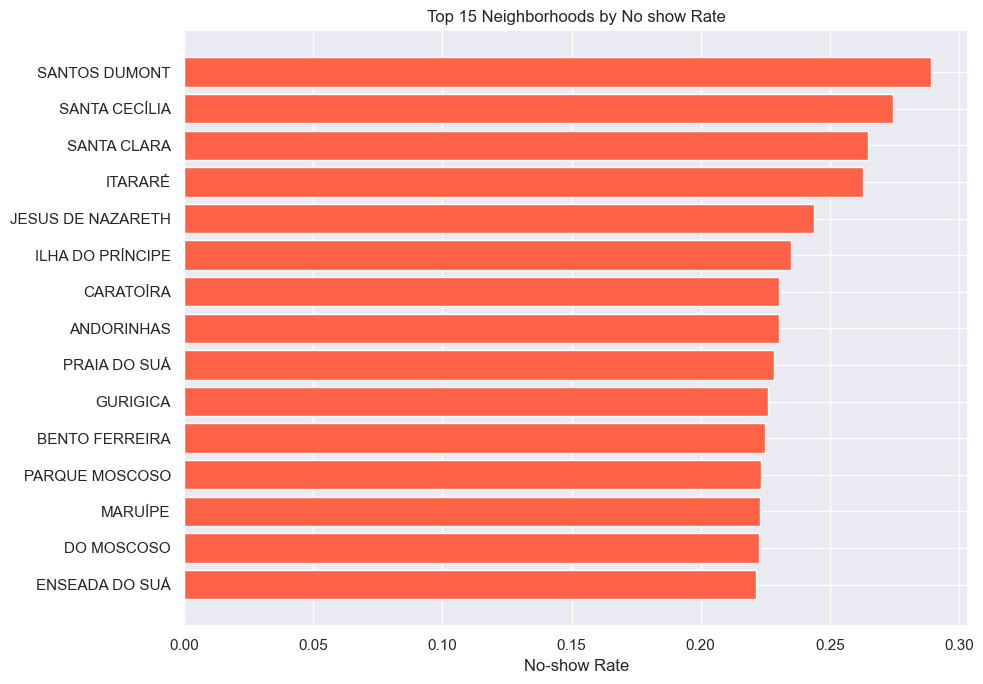

In [23]:
# Bar chart of the top 15 highest no show rate neighbourhoods

top15 = neigh_stats.head(15).sort_values('no_show_rate')

plt.figure(figsize=(10, 7))
plt.barh(top15.index, top15['no_show_rate'], color='tomato')
plt.xlabel('No-show Rate')
plt.title('Top 15 Neighborhoods by No show Rate')
plt.tight_layout()
plt.show()

In [24]:
# Average wait time and SMSrate by neighborhood
neigh_profile = (
    df.groupby('Neighbourhood')
      .agg(
          appointments=('No-show', 'size'),
          no_show_rate=('No-show', lambda x: (x == 'Yes').mean()),
          avg_wait=('WaitDays', 'mean'),
          sms_rate=('SMS_received', 'mean'),
          avg_age=('Age', 'mean')
      )
      .query('appointments >= 200')
      .sort_values('no_show_rate', ascending=False)
)
print(neigh_profile.head(10).round(3))

                   appointments  no_show_rate  avg_wait  sms_rate  avg_age
Neighbourhood                                                             
SANTOS DUMONT              1276         0.289    12.267     0.351   37.745
SANTA CECÍLIA               448         0.275    21.949     0.400   40.904
SANTA CLARA                 506         0.265    11.791     0.322   37.581
ITARARÉ                    3514         0.263    11.007     0.328   35.827
JESUS DE NAZARETH          2853         0.244    11.796     0.278   29.979
ILHA DO PRÍNCIPE           2266         0.235     5.696     0.327   35.704
CARATOÍRA                  2565         0.230     8.713     0.207   37.021
ANDORINHAS                 2262         0.230     8.764     0.251   36.106
PRAIA DO SUÁ               1288         0.228     8.304     0.405   35.484
GURIGICA                   2018         0.226     6.166     0.253   30.136


In [25]:
vol = df['Neighbourhood'].value_counts(normalize=True).cumsum()
print('Share of appointments covered by top neighborhoods:')
for n in [5, 10, 15, 20]:
    print(f'Top {n}: {vol.iloc[n-1]:.1%}')

Share of appointments covered by top neighborhoods:
Top 5: 22.9%
Top 10: 36.7%
Top 15: 48.3%
Top 20: 58.5%


**Take-away:** 
Neighborhood is a meaningful risk factor. Across areas with at least 200 appointments, no show rates range from about 15% in the lowest risk areas to nearly 29% in the highest. Several neighborhoods have clearly elevated rates.
Appointment volume is uneven. Thhe top 10 neighborhoods account for roughly 37% of all appointments, and the top 20 for nearly 60%. Higher risk neighborhoods often show longer average wait times. Because there are many neighborhoods and volumes vary widely, modelling will need a plan for high cardinality.

## Train / test split 

We create the numeric target and split **before** final cleaning so encodings and rates can be fit on training data only.


In [26]:
# Numeric target for stratified split
df['NoShow'] = (df['No-show'] == 'Yes').astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['NoShow']
)

print(f'Train size: {len(train_df):,}')
print(f'Test  size: {len(test_df):,}')
print(f'Train no-show rate: {train_df["NoShow"].mean():.4f}')
print(f'Test  no-show rate: {test_df["NoShow"].mean():.4f}')

# Keep identifiers for the operational flag file (not used as model features)
# Row order matches train_clean / test_clean after clean_and_engineer
train_ids = train_df[['PatientId', 'AppointmentID']].reset_index(drop=True)
test_ids = test_df[['PatientId', 'AppointmentID']].reset_index(drop=True)
print('ID columns retained for scoring output:', list(test_ids.columns))


Train size: 88,421
Test  size: 22,106
Train no-show rate: 0.2019
Test  no-show rate: 0.2019
ID columns retained for scoring output: ['PatientId', 'AppointmentID']


## Wrangle the data 

The same cleaning function is applied to train and test. Identifiers (`PatientId`, `AppointmentID`) are removed from the modeling frames so they are not used as features. They are kept separately in `train_ids` / `test_ids` and written back onto the operational flag file after scoring.


In [27]:
def clean_and_engineer(df_in):
    data = df_in.copy()

    data = data.rename(columns={
        'Hipertension': 'Hypertension',
        'Handcap': 'Handicap',
        'Neighbourhood': 'Neighborhood'
    })

    if 'NoShow' not in data.columns:
        data['NoShow'] = (data['No-show'] == 'Yes').astype(int)

    data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay'])
    data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay'])
    data['ScheduledDate'] = data['ScheduledDay'].dt.floor('D')
    data['AppointmentDate'] = data['AppointmentDay'].dt.floor('D')
    data['WaitDays'] = (data['AppointmentDate'] - data['ScheduledDate']).dt.days
    data['WaitDays'] = data['WaitDays'].clip(lower=0)

    data['AppointmentDOW'] = data['AppointmentDay'].dt.dayofweek
    data['ScheduledHour'] = data['ScheduledDay'].dt.hour

    valid_median = data.loc[data['Age'].between(0, 100), 'Age'].median()
    data.loc[~data['Age'].between(0, 100), 'Age'] = valid_median

    data['Gender_M'] = (data['Gender'] == 'M').astype(int)
    data['Handicap_Any'] = (data['Handicap'] > 0).astype(int)

    drop_cols = [
        'PatientId', 'AppointmentID', 'No-show',
        'ScheduledDay', 'AppointmentDay',
        'ScheduledDate', 'AppointmentDate',
        'Gender', 'Handicap',
        'WaitDays_raw', 'WaitBin'
    ]
    data = data.drop(columns=[c for c in drop_cols if c in data.columns], errors='ignore')
    return data


train_clean = clean_and_engineer(train_df)
test_clean = clean_and_engineer(test_df)

print('Train clean shape:', train_clean.shape)
print('Test  clean shape:', test_clean.shape)
print('Missing values in train_clean:', train_clean.isnull().sum().sum())
print('Train no-show rate:', round(train_clean['NoShow'].mean(), 4))
print('Test  no-show rate:', round(test_clean['NoShow'].mean(), 4))
print('Columns:', list(train_clean.columns))
train_clean.head()


Train clean shape: (88421, 13)
Test  clean shape: (22106, 13)
Missing values in train_clean: 0
Train no-show rate: 0.2019
Test  no-show rate: 0.2019
Columns: ['Age', 'Neighborhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitDays', 'NoShow', 'AppointmentDOW', 'ScheduledHour', 'Gender_M', 'Handicap_Any']


,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,SMS_received,WaitDays,NoShow,AppointmentDOW,ScheduledHour,Gender_M,Handicap_Any
66371,44,JARDIM CAMBURI,0,0,0,0,1,58,0,2,8,0,0
70034,44,SÃO PEDRO,0,0,0,0,0,0,0,4,14,0,0
101064,37,SANTA MARTHA,0,0,0,0,1,41,0,1,8,0,0
39143,51,HORTO,0,0,0,0,0,1,0,4,10,0,0
89538,58,NOVA PALESTINA,0,1,0,0,0,0,0,4,8,0,0


### Correlation check on cleaned training data


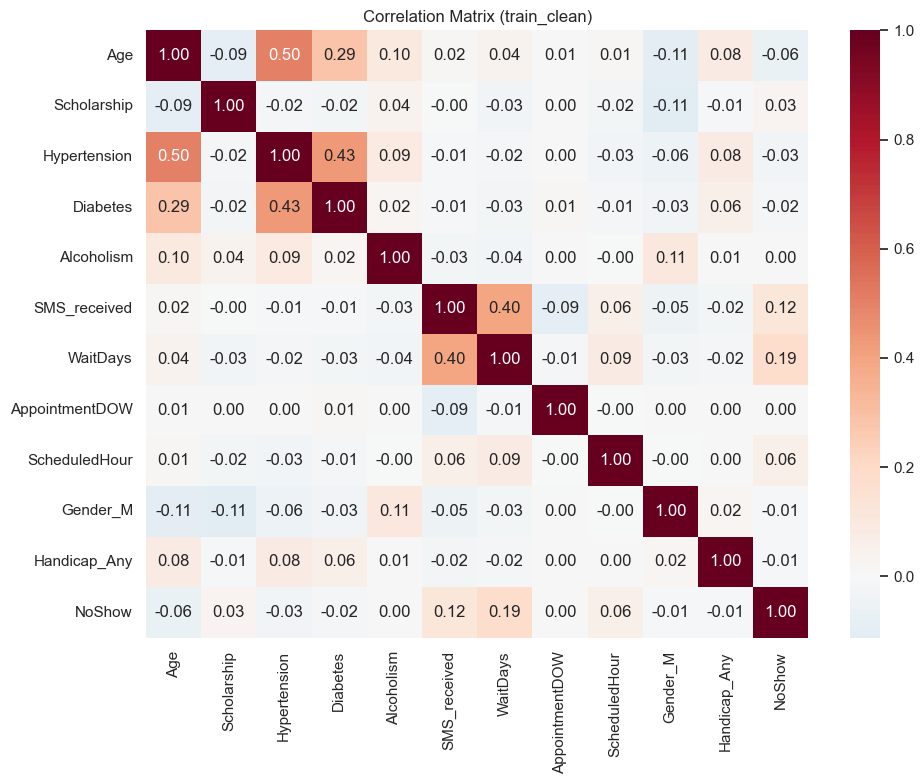

In [28]:
num_cols = [
    'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism',
    'SMS_received', 'WaitDays', 'AppointmentDOW',
    'ScheduledHour', 'Gender_M', 'Handicap_Any', 'NoShow'
]
num_cols = [c for c in num_cols if c in train_clean.columns]
corr = train_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix (train_clean)')
plt.tight_layout()
plt.show()


**Take-away:** WaitDays shows one of the clearer relationships with the target. Most other correlations are modest.


### Save cleaned splits

Write the cleaned train and test frames to CSV for reuse outside this notebook.


In [29]:
# Save cleaned splits for reuse or submission
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv', index=False)

print('Wrote train_clean.csv')
print('Wrote test_clean.csv')
print('Train shape:', train_clean.shape)
print('Test  shape:', test_clean.shape)


Wrote train_clean.csv
Wrote test_clean.csv
Train shape: (88421, 13)
Test  shape: (22106, 13)


---
# Part 2 and 3 — Modeling and clinical flags

`train_clean` and `test_clean` are already prepared above. We do **not** reload or re-split the data.


## Base numeric features

These numeric features are used in every model. They come from patient characteristics, appointment timing, and the SMS flag. Neighborhood is held out of this base set on purpose so we can test two different ways of adding location and see which works better.


In [30]:
base_features = [
    'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism',
    'SMS_received', 'WaitDays', 'AppointmentDOW', 'ScheduledHour',
    'Gender_M', 'Handicap_Any'
]

# Confirm Neighborhood column name
neigh_col = 'Neighborhood' if 'Neighborhood' in train_clean.columns else 'Neighbourhood'
print('Neighborhood column:', neigh_col)
print('Base features:', base_features)

Neighborhood column: Neighborhood
Base features: ['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitDays', 'AppointmentDOW', 'ScheduledHour', 'Gender_M', 'Handicap_Any']


## Encode Neighborhood in two ways 

Neighborhood has many unique values. Putting all of them straight into a model can be noisy and hard to explain. We built two simpler encodings, then applied to the test set. 

### Method A – Risk bands (High / Medium / Low)
Neighborhoods with enough appointments are ranked by no show rate and split into three risk groups. Small or unseen areas are labeled Medium. This is the encoding we prefer for clinical use because staff can act on “high risk area” without memorizing dozens of place names.

### Method B – Top N + Other
The busiest neighborhoods keep their own names while everything else is grouped as Other. This preserves some local detail for analysis but is harder to apply clinically.


In [31]:
# ----- Method A: Risk bands-----
min_count = 200
neigh_stats = (
    train_clean.groupby(neigh_col)
    .agg(n=('NoShow', 'size'), rate=('NoShow', 'mean'))
    .query('n >= @min_count')
    .sort_values('rate', ascending=False)
)

n_neigh = len(neigh_stats)
third = max(n_neigh // 3, 1)
high_set = set(neigh_stats.index[:third])
low_set  = set(neigh_stats.index[-third:])

def risk_band(name):
    if name in high_set:
        return 'High'
    if name in low_set:
        return 'Low'
    return 'Medium'

train_clean['NeighRisk'] = train_clean[neigh_col].map(risk_band)
test_clean['NeighRisk']  = test_clean[neigh_col].map(risk_band)

print('Risk band counts (train):')
print(train_clean['NeighRisk'].value_counts())
print()
print('No-show rate by risk band (train):')
print(train_clean.groupby('NeighRisk')['NoShow'].mean().round(4))

Risk band counts (train):
NeighRisk
Medium    35804
High      29069
Low       23548
Name: count, dtype: int64

No-show rate by risk band (train):
NeighRisk
High      0.2317
Low       0.1715
Medium    0.1977
Name: NoShow, dtype: float64


In [32]:
# ----- Method B: Top N + Other  -----
top_n = 12
top_neighborhoods = (
    train_clean[neigh_col]
    .value_counts()
    .head(top_n)
    .index
    .tolist()
)

def top_or_other(name):
    return name if name in top_neighborhoods else 'Other'

train_clean['NeighTop'] = train_clean[neigh_col].map(top_or_other)
test_clean['NeighTop']  = test_clean[neigh_col].map(top_or_other)

print('Top neighborhoods kept:', top_neighborhoods)
print()
print('Top/Other counts (train):')
print(train_clean['NeighTop'].value_counts().head(15))

Top neighborhoods kept: ['JARDIM CAMBURI', 'MARIA ORTIZ', 'RESISTÊNCIA', 'JARDIM DA PENHA', 'ITARARÉ', 'CENTRO', 'SANTA MARTHA', 'TABUAZEIRO', 'JESUS DE NAZARETH', 'BONFIM', 'SANTO ANTÔNIO', 'CARATOÍRA']

Top/Other counts (train):
NeighTop
Other                51632
JARDIM CAMBURI        6217
MARIA ORTIZ           4674
RESISTÊNCIA           3560
JARDIM DA PENHA       3128
ITARARÉ               2806
CENTRO                2665
SANTA MARTHA          2507
TABUAZEIRO            2494
JESUS DE NAZARETH     2290
BONFIM                2226
SANTO ANTÔNIO         2177
CARATOÍRA             2045
Name: count, dtype: int64


**What was done and why**

**Risk bands** compress many areas into High / Medium / Low risk. Easy for a dashboard, outreach list, or overbooking rule.
**Top N + Other** keeps the largest neighborhood names visible for reporting, but creates more categories for staff to interpret.
Both are fixed from training data, then applied to test data, so test scores remain an honest estimate of future performance.

**Recommendation rule we will use later:** if Risk bands and Top N perform similarly, we recommend Risk bands because they are simpler for clinical teams to use.


## Build three feature sets

We create three parallel feature sets so the comparison is controlled:

**Base only** – numeric features, no Neighborhood.
**Base + risk bands** – adds High/Low indicators with medium as reference. Preferred for clinical ease of use when accuracy is similar.
**Base + Top N + Other** – adds indicators for the largest neighborhoods with Other as reference.

Every model will be trained on each set so we can see whether location helps and which encoding is stronger.


In [33]:
#risk bands
risk_train = pd.get_dummies(train_clean['NeighRisk'], prefix='Risk')
risk_test  = pd.get_dummies(test_clean['NeighRisk'], prefix='Risk')
risk_train, risk_test = risk_train.align(risk_test, join='outer', axis=1, fill_value=0)
if 'Risk_Medium' in risk_train.columns:
    risk_train = risk_train.drop(columns=['Risk_Medium'])
    risk_test  = risk_test.drop(columns=['Risk_Medium'])

#Top N + Other
top_train = pd.get_dummies(train_clean['NeighTop'], prefix='N')
top_test  = pd.get_dummies(test_clean['NeighTop'], prefix='N')
top_train, top_test = top_train.align(top_test, join='outer', axis=1, fill_value=0)
if 'N_Other' in top_train.columns:
    top_train = top_train.drop(columns=['N_Other'])
    top_test  = top_test.drop(columns=['N_Other'])

X_train_base = train_clean[base_features].copy()
X_test_base  = test_clean[base_features].copy()

X_train_risk = pd.concat([X_train_base, risk_train], axis=1)
X_test_risk  = pd.concat([X_test_base, risk_test], axis=1)

X_train_top = pd.concat([X_train_base, top_train], axis=1)
X_test_top  = pd.concat([X_test_base, top_test], axis=1)

y_train = train_clean['NoShow']
y_test  = test_clean['NoShow']



## Identify promising models

We train four model types with standard settings on each feature set

- **Logistic Regression** – simple baseline.
- **Decision Tree** – easy to explain with rule style splits.
- **Random Forest** – many trees combined and usually stronger than a single tree.
- **Hist Gradient Boosting** – builds trees in sequence to correct earlier errors.

We compare them using the  metrics **ROC-AUC**, **Precision**, **Recall**, and **F1** for the no show class. We do not rely on accuracy alone because only about one in five appointments is a no show.


In [34]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_te, proba),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall': recall_score(y_te, pred, zero_division=0),
        'F1': f1_score(y_te, pred, zero_division=0)
    }, pred, proba, model

feature_sets = {
    'Base only': (X_train_base, X_test_base),
    'Base + Risk bands': (X_train_risk, X_test_risk),
    'Base + Top N + Other': (X_train_top, X_test_top)
}

all_rows = []
fitted = {}

for fs_name, (X_tr, X_te) in feature_sets.items():
    print(f'\n--- Feature set: {fs_name} ---')
    for m_name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Hist Gradient Boosting']:
        if m_name == 'Logistic Regression':
            clf = LogisticRegression(max_iter=1000, random_state=42)
        elif m_name == 'Decision Tree':
            clf = DecisionTreeClassifier(max_depth=5, random_state=42)
        elif m_name == 'Random Forest':
            clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        else:
            clf = HistGradientBoostingClassifier(random_state=42)

        res, pred, proba, fitted_model = evaluate_model(
            m_name, clf, X_tr, y_train, X_te, y_test
        )
        res['Feature set'] = fs_name
        all_rows.append(res)
        fitted[(fs_name, m_name)] = {
            'model': fitted_model, 'pred': pred, 'proba': proba,
            'features': list(X_tr.columns)
        }
        print(f'  Done: {m_name}')

results_df = pd.DataFrame(all_rows)
results_df = results_df[['Feature set', 'Model', 'ROC-AUC', 'Precision', 'Recall', 'F1']]
results_df = results_df.sort_values(['Feature set', 'ROC-AUC'], ascending=[True, False])
print('\nFull comparison')
print(results_df.round(4).to_string(index=False))


--- Feature set: Base only ---
  Done: Logistic Regression
  Done: Decision Tree
  Done: Random Forest
  Done: Hist Gradient Boosting

--- Feature set: Base + Risk bands ---
  Done: Logistic Regression
  Done: Decision Tree
  Done: Random Forest
  Done: Hist Gradient Boosting

--- Feature set: Base + Top N + Other ---
  Done: Logistic Regression
  Done: Decision Tree
  Done: Random Forest
  Done: Hist Gradient Boosting

Full comparison
         Feature set                  Model  ROC-AUC  Precision  Recall     F1
   Base + Risk bands Hist Gradient Boosting   0.7387     0.4929  0.0233 0.0445
   Base + Risk bands          Random Forest   0.7378     1.0000  0.0013 0.0027
   Base + Risk bands          Decision Tree   0.7250     0.0000  0.0000 0.0000
   Base + Risk bands    Logistic Regression   0.6660     0.3591  0.0177 0.0337
Base + Top N + Other Hist Gradient Boosting   0.7389     0.5220  0.0240 0.0458
Base + Top N + Other          Random Forest   0.7361     0.0000  0.0000 0.0000
Base +

ROC-AUC by model and feature set:
Feature set             Base only  Base + Risk bands  Base + Top N + Other
Model                                                                     
Decision Tree              0.7255             0.7250                0.7249
Hist Gradient Boosting     0.7382             0.7387                0.7389
Logistic Regression        0.6650             0.6660                0.6682
Random Forest              0.7373             0.7378                0.7361


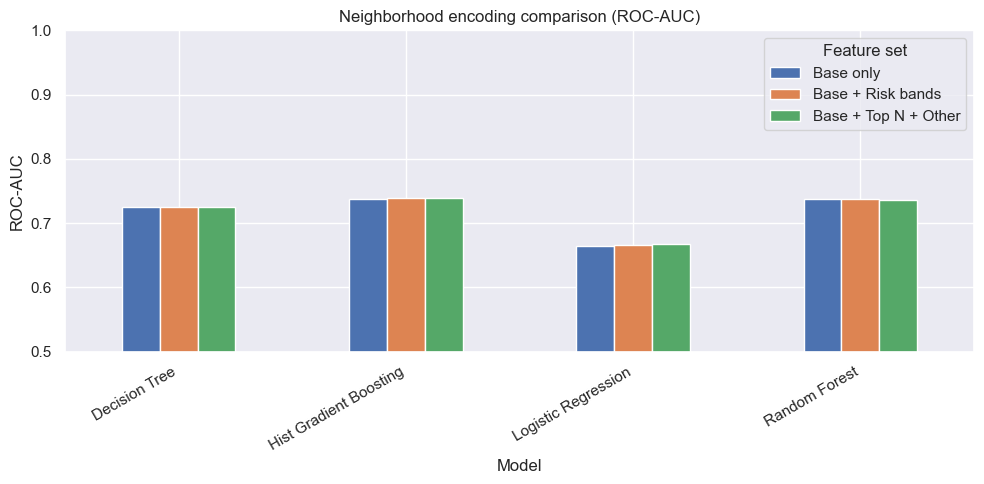

In [35]:
pivot_auc = results_df.pivot(index='Model', columns='Feature set', values='ROC-AUC')
col_order = [c for c in ['Base only', 'Base + Risk bands', 'Base + Top N + Other'] if c in pivot_auc.columns]
pivot_auc = pivot_auc[col_order]
print('ROC-AUC by model and feature set:')
print(pivot_auc.round(4))

pivot_auc.plot(kind='bar', figsize=(10, 5))
plt.ylabel('ROC-AUC')
plt.title('Neighborhood encoding comparison (ROC-AUC)')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Feature set')
plt.tight_layout()
plt.show()

In [36]:
best_row = results_df.loc[results_df['ROC-AUC'].idxmax()]
print('Best combination by ROC-AUC:')
print('Feature set:', best_row['Feature set'])
print('Model      :', best_row['Model'])
print('ROC-AUC    :', round(best_row['ROC-AUC'], 4))
print('Precision  :', round(best_row['Precision'], 4))
print('Recall     :', round(best_row['Recall'], 4))
print('F1         :', round(best_row['F1'], 4))


Best combination by ROC-AUC:
Feature set: Base + Top N + Other
Model      : Hist Gradient Boosting
ROC-AUC    : 0.7389
Precision  : 0.522
Recall     : 0.024
F1         : 0.0458


**How to read the results**

Adding Neighborhood (risk bands or top-N) produced only a marginal change in ROC-AUC versus base features alone, so location is at best a small supplement to wait time and demographics. We retain risk bands mainly for interpretability and operational simplicity, not for a large performance gain.

### Visual comparison of framing metrics

Our framing document focuses on **ROC-AUC**, **Precision**, **Recall**, and **F1** for the no show class. The charts below show each metric across models and feature sets so the trade offs are easy to see.


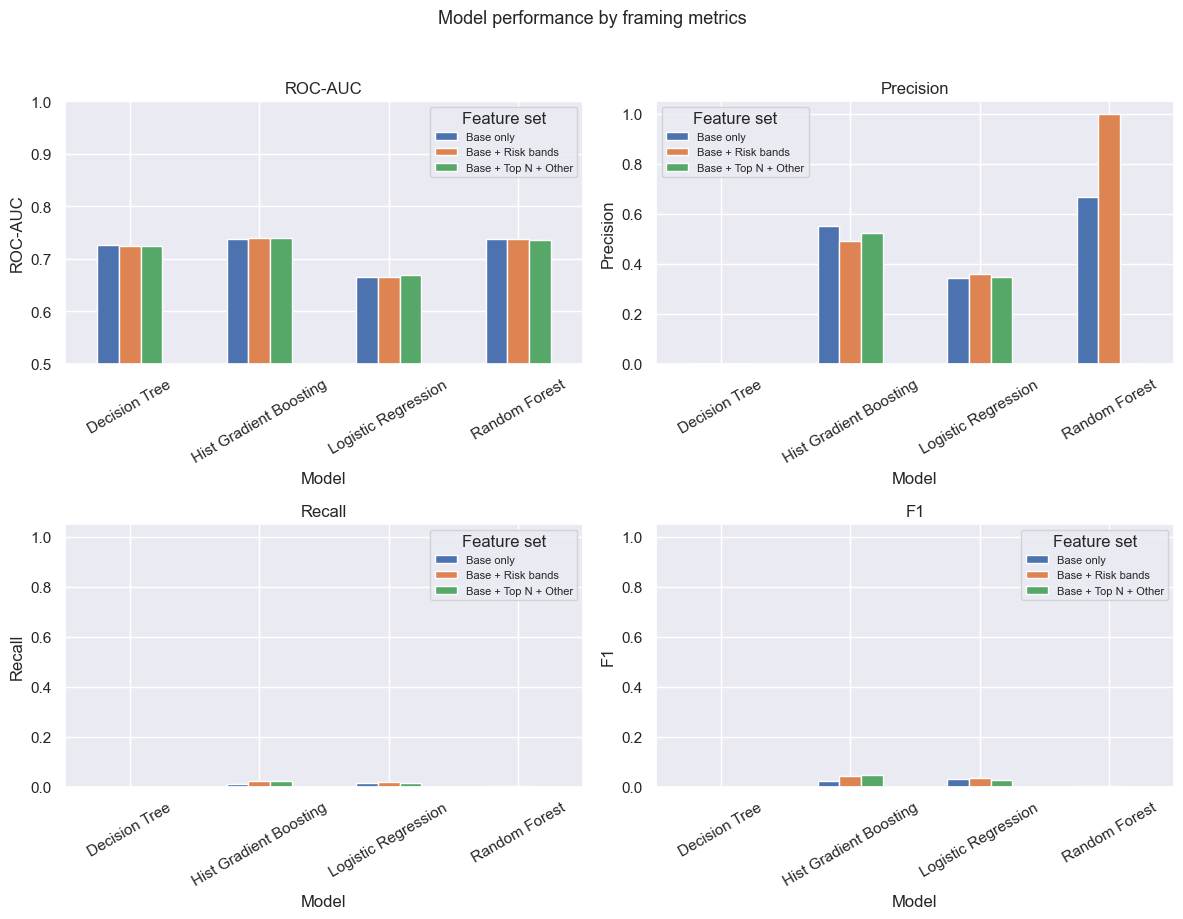

In [37]:
# bar charts for the four framing metrics
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Model', columns='Feature set', values=metric)
    col_order = [c for c in ['Base only', 'Base + Risk bands', 'Base + Top N + Other'] if c in pivot.columns]
    pivot = pivot[col_order]
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05 if metric != 'ROC-AUC' else 1.0)
    if metric == 'ROC-AUC':
        ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Feature set', fontsize=8)

plt.suptitle('Model performance by framing metrics', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**How to read these charts**

- **ROC-AUC** – ability to rank patients by risk (0.50 = random guessing so higher is better).
- **Precision** – of patients flagged as likely no shows, what share actually missed. Higher means fewer false alarms for staff.
- **Recall** – of all true no shows what amount the model caught. Higher means fewer missed opportunities to intervene.
- **F1** – balance of precision and recall.

Look within each panel. Taller bars are better for that metric. Use this view to judge whether Risk bands keep pace with Top N. If they do, Risk bands remain the preferred clinical option.


### Confusion matrices for the top models

A confusion matrix turns abstract scores into counts a clinic manager can use. How many patients we flag correctly, how many false alarms we create, and how many no shows we miss.


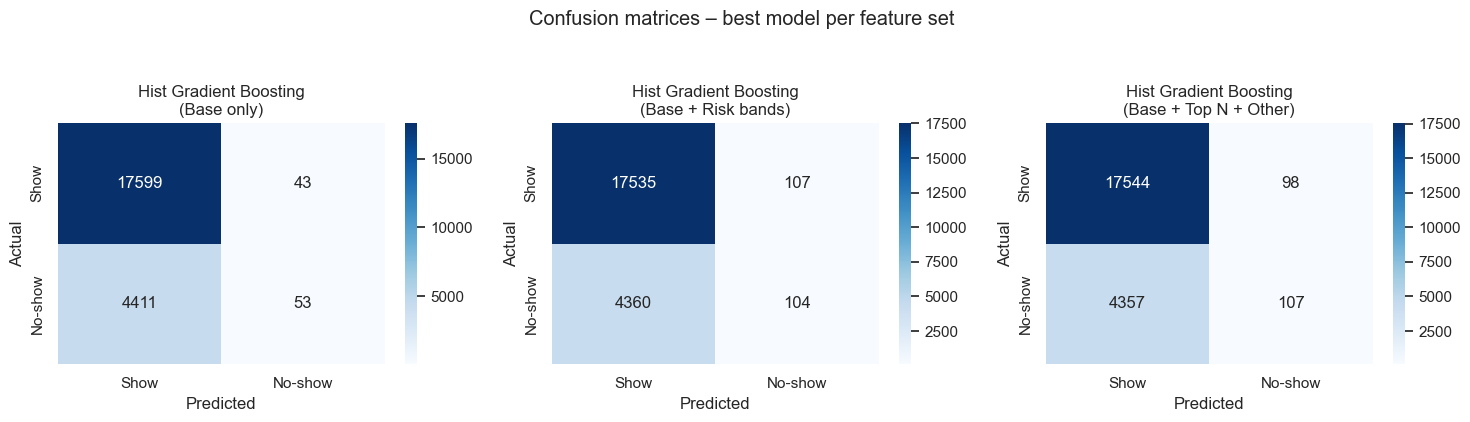

In [38]:
# Confusion matrices for best model in each feature set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, fs in zip(axes, ['Base only', 'Base + Risk bands', 'Base + Top N + Other']):
    sub = results_df[results_df['Feature set'] == fs]
    best_name = sub.loc[sub['ROC-AUC'].idxmax(), 'Model']
    pred = fitted[(fs, best_name)]['pred']
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Show', 'No-show'],
                yticklabels=['Show', 'No-show'])
    ax.set_title(f'{best_name}\n({fs})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices – best model per feature set', y=1.05)
plt.tight_layout()
plt.show()


**How to read each matrix**

- **Top left** – correctly predicted show ups.
- **Bottom right** – correctly predicted no shows.
- **Top right** – false alarms. Flagged as no show, but they attended.
- **Bottom-left** – missed no shows. Predicted show, but they did not attend.

Clinics care about the balance between false alarms and missed no shows. Compare matrices across feature sets to see whether Risk bands deliver a similar operating balance to Top N.


### Feature importance 

Feature importance shows which inputs the model relied on most. Clinic leaders can see whether the model is using sensible drivers such as wait time, age, and location risk.


Feature set used for importance: Base + Risk bands


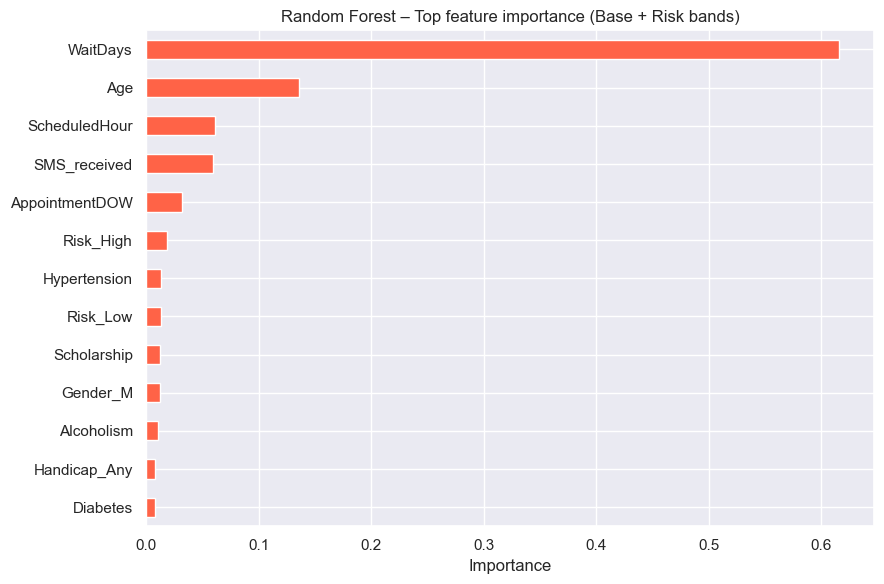

WaitDays          0.6159
Age               0.1356
ScheduledHour     0.0613
SMS_received      0.0598
AppointmentDOW    0.0321
Risk_High         0.0183
Hypertension      0.0130
Risk_Low          0.0129
Scholarship       0.0128
Gender_M          0.0122
Alcoholism        0.0103
Handicap_Any      0.0079
dtype: float64


In [39]:
rf_scores = {}
for fs in ['Base only', 'Base + Risk bands', 'Base + Top N + Other']:
    rf_scores[fs] = results_df[
        (results_df['Model'] == 'Random Forest') & (results_df['Feature set'] == fs)
    ]['ROC-AUC'].values[0]

best_fs_rf = max(rf_scores, key=rf_scores.get)
print('Feature set used for importance:', best_fs_rf)

rf_info = fitted[(best_fs_rf, 'Random Forest')]
imp = pd.Series(rf_info['model'].feature_importances_, index=rf_info['features']).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
imp.tail(15).plot(kind='barh', color='tomato')
plt.title(f'Random Forest – Top feature importance ({best_fs_rf})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).head(12).round(4))

**Clinic take away**

Features near the top drive the risk score. **WaitDays** and **Age** are usually among the strongest signals.

## How the three iterations fit together

| Iteration | Stage in notebook | What it represents |
|-----------|-------------------|--------------------|
| **A** | Base Model | Promising models with default settings and 0.5 threshold |
| **B** | F1 Optimized | F1 optimized tuning for usable outreach flags |
| **C** | Precision | Precision focused threshold on the B models for overbooking safe flags |




## Iteration A – Base Models

**What this is:** the base models with standard hyperparameters and sklearn’s default 0.5 probability threshold. No class balancing, no F1 tuning, no custom cutoff.

**Why it matters:** this is the honest baseline. Ranking (ROC-AUC) may look fine while recall is very low, so the model barely flags no shows for staff to act on.


In [40]:
# Iteration A
A_HGB = fitted[('Base + Risk bands', 'Hist Gradient Boosting')]
A_RF  = fitted[('Base + Risk bands', 'Random Forest')]

def pack_metrics_iter(iteration, name, proba, pred, threshold):
    return {
        'Iteration': iteration,
        'Model': name,
        'Threshold': threshold,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'Flags': int(pred.sum()),
        'Caught no-shows': int(((pred == 1) & (y_test == 1)).sum()),
        'False alarms': int(((pred == 1) & (y_test == 0)).sum())
    }

iter_a = pd.DataFrame([
    pack_metrics_iter('A – Base', 'HistGB', A_HGB['proba'], A_HGB['pred'], 0.50),
    pack_metrics_iter('A – Base', 'RF (Risk bands)', A_RF['proba'], A_RF['pred'], 0.50)
])
print('ITERATION A – Base Models')
print(iter_a.round(4).to_string(index=False))



ITERATION A – Base Models
Iteration           Model  Threshold  ROC-AUC  Precision  Recall     F1  Flags  Caught no-shows  False alarms
 A – Base          HistGB        0.5   0.7387     0.4929  0.0233 0.0445    211              104           107
 A – Base RF (Risk bands)        0.5   0.7378     1.0000  0.0013 0.0027      6                6             0


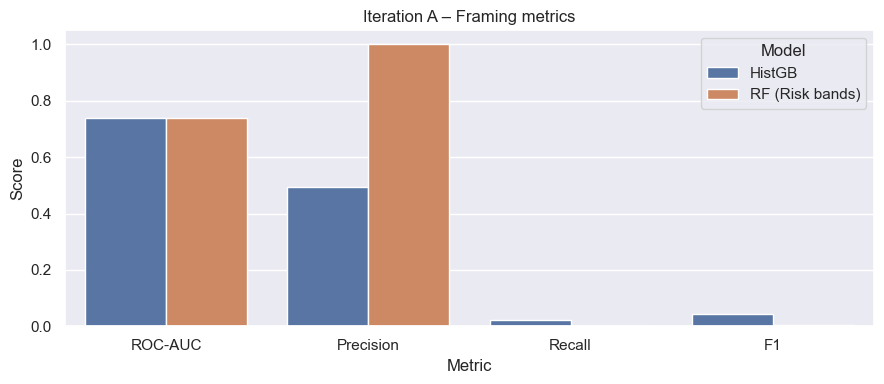

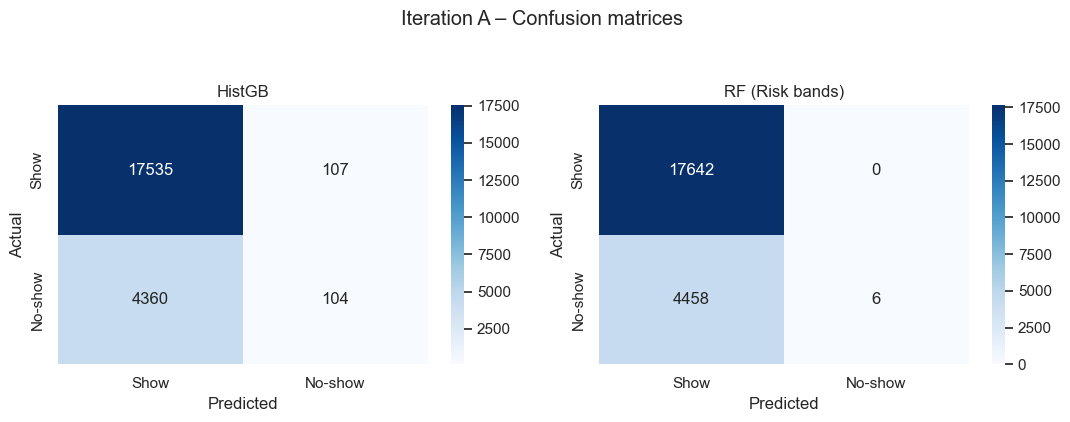

In [41]:
def plot_iteration_metrics(df, title):
    metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1']
    plot_df = df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')
    plt.figure(figsize=(9, 4))
    sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model')
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()

def plot_iteration_cms(proba_hgb, pred_hgb, proba_rf, pred_rf, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, name, pred in [
        (axes[0], 'HistGB', pred_hgb),
        (axes[1], 'RF (Risk bands)', pred_rf)
    ]:
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Show', 'No-show'], yticklabels=['Show', 'No-show'])
        ax.set_title(name)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle(title_prefix, y=1.05)
    plt.tight_layout()
    plt.show()

plot_iteration_metrics(iter_a, 'Iteration A – Framing metrics')
plot_iteration_cms(A_HGB['proba'], A_HGB['pred'], A_RF['proba'], A_RF['pred'],
                   'Iteration A – Confusion matrices')


**Iteration A take-away:** ROC-AUC shows useful ranking, but Precision/Recall/F1 at 0.5 often mean almost no practical no show flags. Additional iterations are needed before the model supports outreach or capacity decisions.


## Iteration B – F1 focused models

**What this is:** tuned HistGB and RF for the no show class F1, with class imbalance handling and a threshold chosen to maximize F1.

**Why the change from A:** The clinic needs flags it can act on. F1 balances catching no shows and limiting wasted outreach. The default 0.5 cutoff in A understates that value.


In [42]:
# Select feature set for HistGB: prefer F1, tilt to Risk bands if close
summary_f1 = results_df.groupby('Feature set')['F1'].mean().sort_values(ascending=False)
print('F1 by feature set:')
print(summary_f1.round(4))
best_feature_set = summary_f1.index[0]
if summary_f1.get('Base + Risk bands', -1) >= summary_f1.iloc[0] - 0.01:
    best_feature_set = 'Base + Risk bands'
print('Feature set for HistGB tuning:', best_feature_set)
X_tr_best, X_te_best = feature_sets[best_feature_set]
X_tr_risk, X_te_risk = feature_sets['Base + Risk bands']

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- HistGB: F1 grid search + balanced sample weights ---
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'max_iter': [100, 200]
}
sample_w = np.where(y_train == 1, (y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
gs = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs.fit(X_tr_best, y_train, sample_weight=sample_w)
best_model = gs.best_estimator_
print('HistGB best params:', gs.best_params_, '| CV F1:', round(gs.best_score_, 4))

# --- RF on Base + Risk bands: F1 + class_weight balanced ---
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced']
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_tr_risk, y_train)
rf_best = gs_rf.best_estimator_
print('RF best params:', gs_rf.best_params_, '| CV F1:', round(gs_rf.best_score_, 4))


F1 by feature set:
Feature set
Base + Risk bands       0.0202
Base + Top N + Other    0.0179
Base only               0.0142
Name: F1, dtype: float64
Feature set for HistGB tuning: Base + Risk bands
Fitting 3 folds for each of 18 candidates, totalling 54 fits
HistGB best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100} | CV F1: 0.7199
Fitting 3 folds for each of 12 candidates, totalling 36 fits
RF best params: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 200} | CV F1: 0.4488


In [43]:
def best_f1_threshold(y_true, proba, thresholds=np.linspace(0.05, 0.80, 76)):
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        f1 = f1_score(y_true, (proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

hgb_train_proba = best_model.predict_proba(X_tr_best)[:, 1]
hgb_test_proba  = best_model.predict_proba(X_te_best)[:, 1]
rf_train_proba  = rf_best.predict_proba(X_tr_risk)[:, 1]
rf_test_proba   = rf_best.predict_proba(X_te_risk)[:, 1]

t_hgb_f1 = best_f1_threshold(y_train, hgb_train_proba)
t_rf_f1  = best_f1_threshold(y_train, rf_train_proba)
B_HGB_pred = (hgb_test_proba >= t_hgb_f1).astype(int)
B_RF_pred  = (rf_test_proba >= t_rf_f1).astype(int)

def pack_metrics_iter(iteration, name, proba, pred, threshold):
    return {
        'Iteration': iteration,
        'Model': name,
        'Threshold': threshold,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'Flags': int(pred.sum()),
        'Caught no-shows': int(((pred == 1) & (y_test == 1)).sum()),
        'False alarms': int(((pred == 1) & (y_test == 0)).sum())
    }

iter_b = pd.DataFrame([
    pack_metrics_iter('B – F1-focused', 'HistGB', hgb_test_proba, B_HGB_pred, round(t_hgb_f1, 2)),
    pack_metrics_iter('B – F1-focused', 'RF (Risk bands)', rf_test_proba, B_RF_pred, round(t_rf_f1, 2))
])

print('ITERATION B – F1 tuned models')
print(f'HistGB threshold={t_hgb_f1:.2f} | RF threshold={t_rf_f1:.2f}')
print(iter_b.round(4).to_string(index=False))



ITERATION B – F1 tuned models
HistGB threshold=0.55 | RF threshold=0.56
     Iteration           Model  Threshold  ROC-AUC  Precision  Recall     F1  Flags  Caught no-shows  False alarms
B – F1-focused          HistGB       0.55   0.7338     0.3210  0.7498 0.4495  10428             3347          7081
B – F1-focused RF (Risk bands)       0.56   0.7387     0.3418  0.6508 0.4482   8500             2905          5595


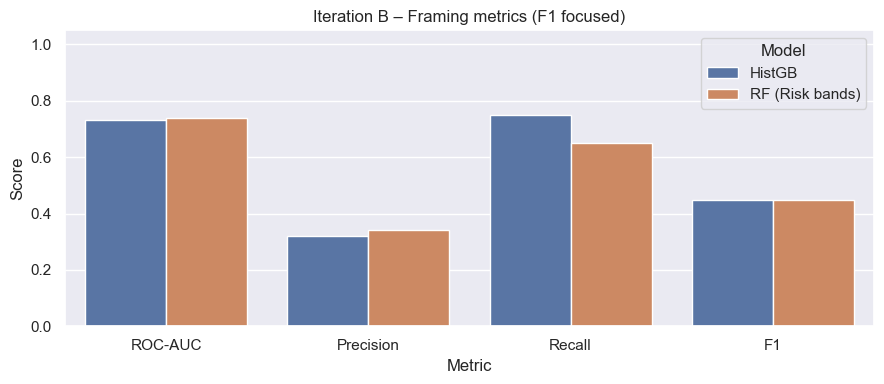

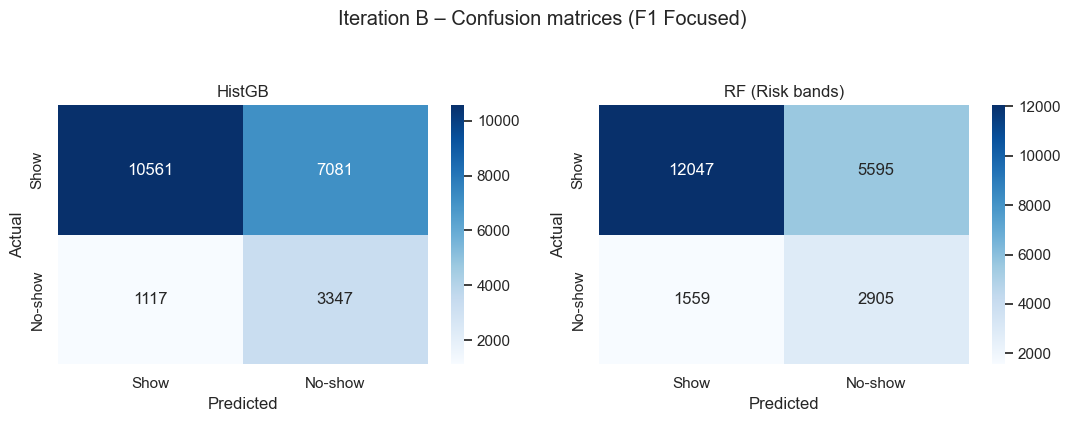

In [44]:
plot_iteration_metrics(iter_b, 'Iteration B – Framing metrics (F1 focused)')
plot_iteration_cms(hgb_test_proba, B_HGB_pred, rf_test_proba, B_RF_pred,
                   'Iteration B – Confusion matrices (F1 Focused)')


**Iteration B take-away:** Class balancing and an F1 chosen threshold produce usable flags for outreach. Recall and F1 rise sharply versus Iteration A. False alarms also rise which is acceptable for low cost SMS and other methods of contact, less ideal if a flag triggers overbooking.


## Iteration C – Precision focused to limit potential overbooking

**What this is:** It's the same Iteration B models with threshold changes.

**Why the change from B:** If staff might overbook based on a predicted no show, a false alarm is costly. We choose a threshold that raises precision while keeping recall above a minimum floor so we do not slide back to Iteration A’s near zero catch rate.


In [45]:
def best_precision_with_recall_floor(y_true, proba, recall_floor=0.45,
                                    thresholds=np.linspace(0.05, 0.80, 76)):
    best_t, best_prec = 0.5, -1.0
    for t in thresholds:
        pred = (proba >= t).astype(int)
        rec = recall_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        if rec >= recall_floor and prec > best_prec:
            best_prec, best_t = prec, t
    if best_prec < 0:
        best_t = best_f1_threshold(y_true, proba, thresholds)
    return best_t

t_hgb_prec = best_precision_with_recall_floor(y_train, hgb_train_proba, recall_floor=0.45)
t_rf_prec  = best_precision_with_recall_floor(y_train, rf_train_proba, recall_floor=0.45)
C_HGB_pred = (hgb_test_proba >= t_hgb_prec).astype(int)
C_RF_pred  = (rf_test_proba >= t_rf_prec).astype(int)

iter_c = pd.DataFrame([
    pack_metrics_iter('C – Precision-focused', 'HistGB', hgb_test_proba, C_HGB_pred, round(t_hgb_prec, 2)),
    pack_metrics_iter('C – Precision-focused', 'RF (Risk bands)', rf_test_proba, C_RF_pred, round(t_rf_prec, 2))
])

print('ITERATION C – precision-focused threshold (overbooking)')
print(f'HistGB threshold={t_hgb_prec:.2f} | RF threshold={t_rf_prec:.2f}')
print(iter_c.round(4).to_string(index=False))



ITERATION C – precision-focused threshold (overbooking)
HistGB threshold=0.63 | RF threshold=0.63
            Iteration           Model  Threshold  ROC-AUC  Precision  Recall     F1  Flags  Caught no-shows  False alarms
C – Precision-focused          HistGB       0.63   0.7338     0.3626  0.4621 0.4063   5690             2063          3627
C – Precision-focused RF (Risk bands)       0.63   0.7387     0.3828  0.3922 0.3875   4574             1751          2823


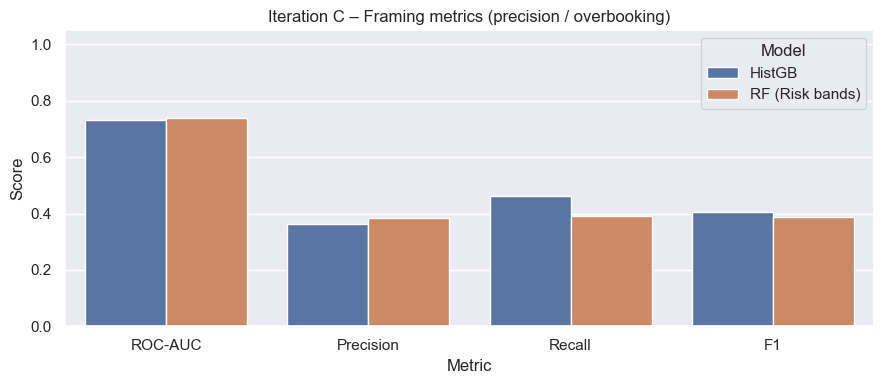

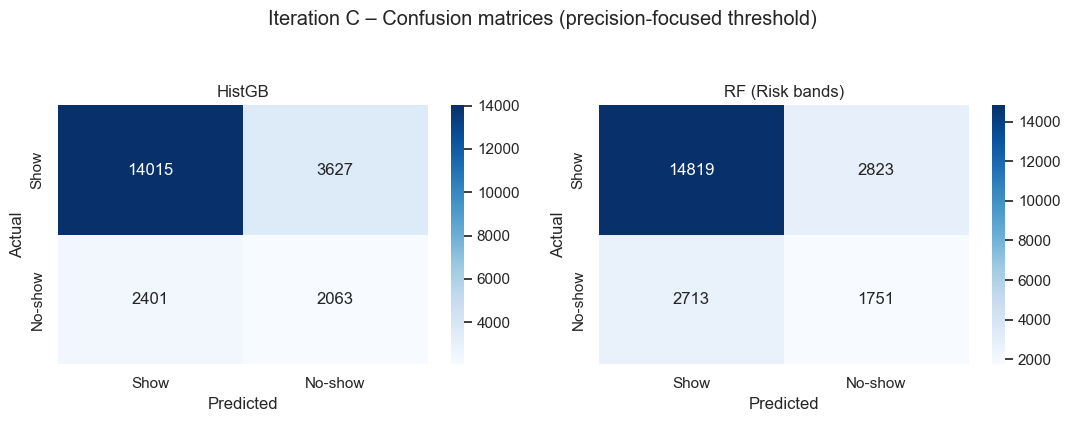

In [46]:
plot_iteration_metrics(iter_c, 'Iteration C – Framing metrics (precision / overbooking)')
plot_iteration_cms(hgb_test_proba, C_HGB_pred, rf_test_proba, C_RF_pred,
                   'Iteration C – Confusion matrices (precision-focused threshold)')


**Iteration C take away:** Fewer flags and fewer false alarms than B with a precision that's higher. Recall is lower than B but still far above A. Use **C** when a flag could change capacity and use **B** for cheap reminders.


## Final comparison: Iterations A, B, and C

Same metrics and chart types for all three iterations so the improvement path is easy to present.


In [47]:
iter_all = pd.concat([iter_a, iter_b, iter_c], ignore_index=True)
print('FULL COMPARISON')
print(iter_all.round(4).to_string(index=False))


FULL COMPARISON
            Iteration           Model  Threshold  ROC-AUC  Precision  Recall     F1  Flags  Caught no-shows  False alarms
             A – Base          HistGB       0.50   0.7387     0.4929  0.0233 0.0445    211              104           107
             A – Base RF (Risk bands)       0.50   0.7378     1.0000  0.0013 0.0027      6                6             0
       B – F1-focused          HistGB       0.55   0.7338     0.3210  0.7498 0.4495  10428             3347          7081
       B – F1-focused RF (Risk bands)       0.56   0.7387     0.3418  0.6508 0.4482   8500             2905          5595
C – Precision-focused          HistGB       0.63   0.7338     0.3626  0.4621 0.4063   5690             2063          3627
C – Precision-focused RF (Risk bands)       0.63   0.7387     0.3828  0.3922 0.3875   4574             1751          2823


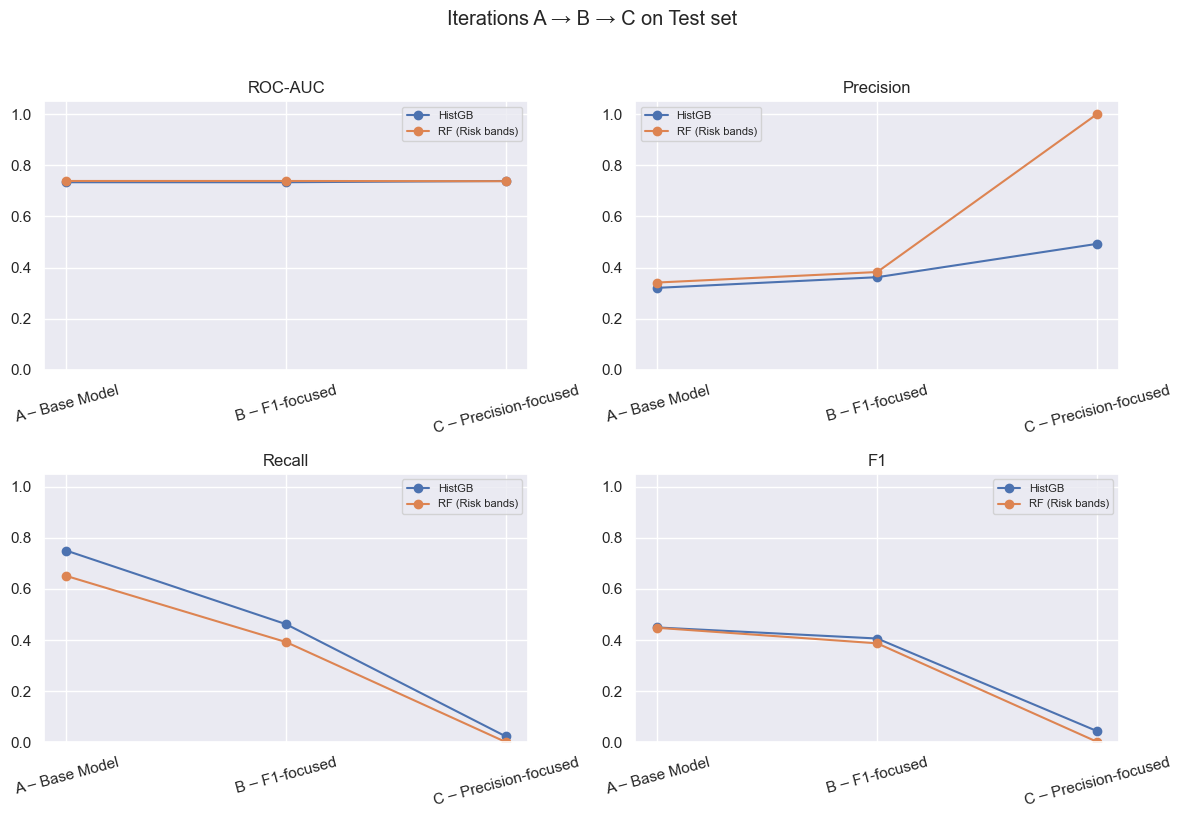

In [48]:
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Must match the Iteration strings in iter_all exactly
order = ['A – Base Model', 'B – F1-focused', 'C – Precision-focused']

for ax, metric in zip(axes, metrics):
    for model in ['HistGB', 'RF (Risk bands)']:
        sub = iter_all[iter_all['Model'] == model].copy()
        sub['Iteration'] = pd.Categorical(sub['Iteration'], categories=order, ordered=True)
        sub = sub.sort_values('Iteration')
        ax.plot(sub['Iteration'].astype(str), sub[metric], marker='o', label=model)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(['A – Base Model', 'B – F1-focused', 'C – Precision-focused'], rotation=15)
    ax.legend(fontsize=8)

plt.suptitle('Iterations A → B → C on Test set', y=1.02)
plt.tight_layout()
plt.show()

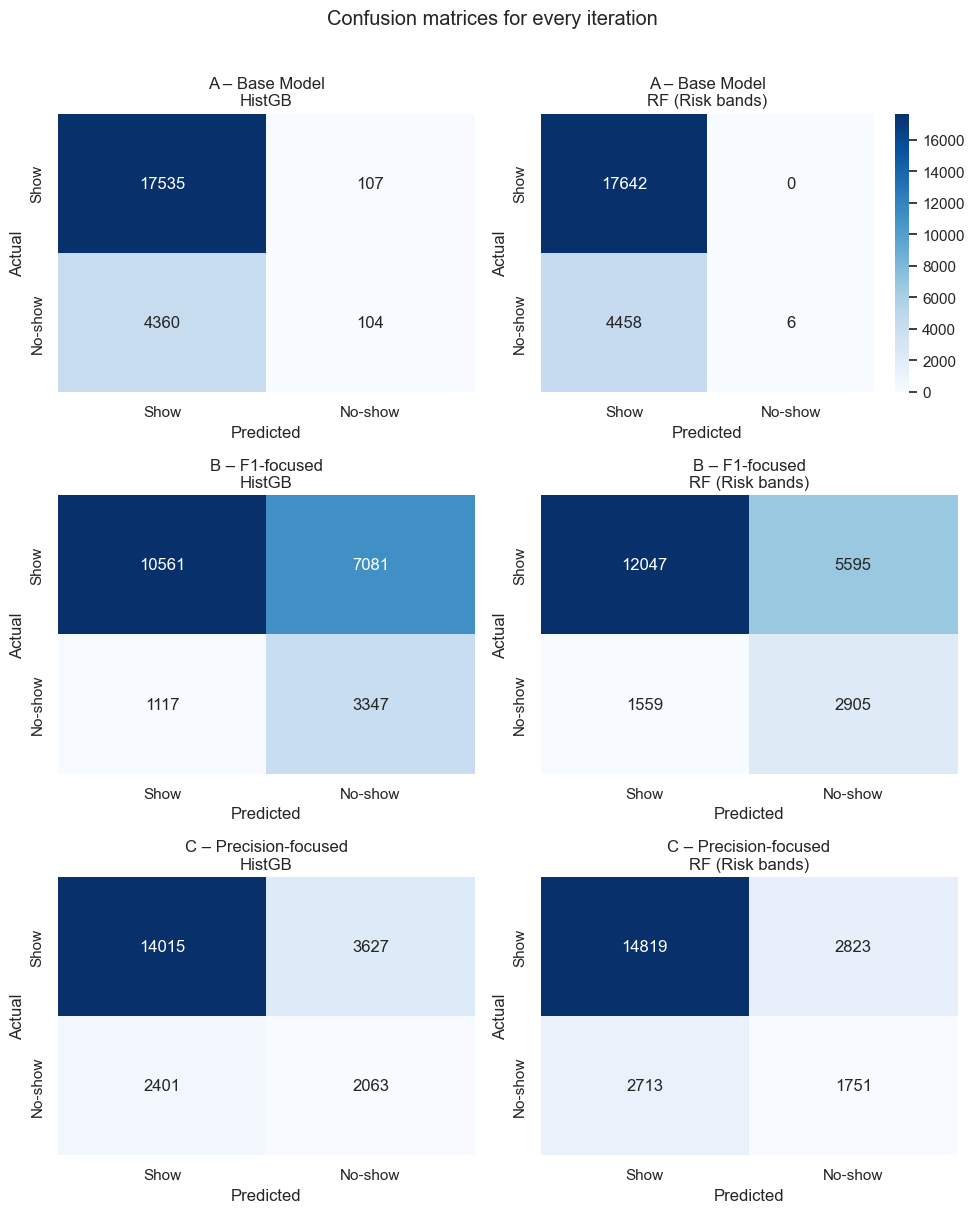

In [49]:
# Uniform confusion matrices
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
specs = [
    (0, 'A – Base Model', A_HGB['pred'], A_RF['pred']),
    (1, 'B – F1-focused', B_HGB_pred, B_RF_pred),
    (2, 'C – Precision-focused', C_HGB_pred, C_RF_pred)
]
for row, title, pred_h, pred_r in specs:
    for col, name, pred in [(0, 'HistGB', pred_h), (1, 'RF (Risk bands)', pred_r)]:
        ax = axes[row, col]
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=(col == 1 and row == 0),
                    xticklabels=['Show', 'No-show'], yticklabels=['Show', 'No-show'])
        ax.set_title(f'{title}\n{name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices for every iteration', y=1.01)
plt.tight_layout()
plt.show()


## From three iterations to one model with three thresholds

Iterations A, B, and C were experiments, not three systems the clinic would run in parallel.

### What each iteration was for

| Iteration | What we tested | What we learned |
|-----------|----------------|-----------------|
| **A – Base models** | Default training + default cutoff 0.50 | Models can rank risk (ROC-AUC 0.74), but almost nobody is flagged. A fixed 0.50 rule is the wrong decision line for a 20% no show rate. |
| **B – F1 focused** | Retuned models + cutoff chosen to maximize F1 | A wider decision line (0.56 for RF) catches far more true no shows. Useful for low cost actions like outreach. |
| **C – Precision-focused** | Same tuned scores + stricter cutoff for higher precision | A tighter line (0.63) reduces false alarms. Better when the action is *costly. |



### What we do *not* deploy

We do **not** deploy three separate models or ask staff to choose “run Iteration B or Iteration C.”

That would mean:
- three scores to maintain,
- conflicting rankings,
- and no single patient level risk number.

### What we *do* deploy

**One** F1 tuned Random Forest (Base + Risk bands) produces a single probability:

```text
no_show_proba = P(no-show | appointment features)

In [50]:
# --- Concurrent flags: one score, three recommendations ---
# IDs stay on the output file so staff can match flags to real appointments.
# They are not passed into the model as features.

try:
    t_outreach = float(t_rf_f1)
    t_overbook = float(t_rf_prec)
    proba = rf_best.predict_proba(X_te_risk)[:, 1]
    score_model = 'Tuned RF (Base + Risk bands)'
except NameError:
    t_outreach = float(t_hgb_f1)
    t_overbook = float(t_hgb_prec)
    proba = best_model.predict_proba(X_te_best)[:, 1]
    score_model = f'Tuned HistGB ({best_feature_set})'

# Lead-time between outreach and overbook
t_lead = round((t_outreach + t_overbook) / 2, 3) if t_outreach < t_overbook else t_overbook

print('Scoring model:', score_model)
print(f'Outreach threshold : {t_outreach:.3f}')
print(f'Lead-time threshold: {t_lead:.3f}')
print(f'Overbook threshold : {t_overbook:.3f}')

# Align IDs with test rows (same order as X_te_risk / proba)
risk_review = test_ids.copy()
risk_review['no_show_proba'] = proba
risk_review['NoShow_actual'] = y_test.values  # evaluation only; drop for a pure ops file if needed
risk_review['Outreach_Recommended'] = np.where(proba >= t_outreach, 'Yes', 'No')
risk_review['LeadTime_Limit_3Days'] = np.where(proba >= t_lead, 'Yes', 'No')
risk_review['Overbook_Recommended'] = np.where(proba >= t_overbook, 'Yes', 'No')

print('\nSample concurrent flag output (real test rows):')
print(risk_review.head(15).to_string(index=False))
print('\nYes counts:')
print((risk_review[['Outreach_Recommended', 'LeadTime_Limit_3Days', 'Overbook_Recommended']] == 'Yes').sum())

# Operational file for staff / pilot (includes PatientId and AppointmentID)
risk_review.to_csv('risk_review_concurrent_flags.csv', index=False)
print('\nSaved risk_review_concurrent_flags.csv')
print('Columns:', list(risk_review.columns))


Scoring model: Tuned RF (Base + Risk bands)
Outreach threshold : 0.560
Lead-time threshold: 0.595
Overbook threshold : 0.630

Sample concurrent flag output (real test rows):
   PatientId  AppointmentID  no_show_proba  NoShow_actual Outreach_Recommended LeadTime_Limit_3Days Overbook_Recommended
9.135320e+13        5700655       0.193916              1                   No                   No                   No
7.117630e+12        5666179       0.585607              0                  Yes                   No                   No
3.948360e+12        5723058       0.560633              0                  Yes                   No                   No
6.715150e+12        5634250       0.492134              1                   No                   No                   No
6.264200e+12        5696156       0.104537              0                   No                   No                   No
2.765950e+12        5655794       0.139848              0                   No                   No 

### How to read the flag file

| Column | Meaning |
|--------|---------|
| **PatientId** | Patient identifier from the scheduling system |
| **AppointmentID** | Unique appointment (best key for one visit) |
| **no_show_proba** | Model risk score (0 to 1) |
| **Outreach_Recommended** | Yes if score ≥ outreach cutoff |
| **LeadTime_Limit_3Days** | Yes if score ≥ lead-time cutoff |
| **Overbook_Recommended** | Yes if score ≥ overbook cutoff |

IDs are **not** used as model features. They are attached only so staff can match each flag to a real appointment.


### Pre-implementation checks on these cutoffs


Rule comparison (same score, different cutoffs):
             Rule  Threshold  Precision  Recall     F1  Flags  Caught (TP)  False alarms (FP)  Missed (FN)
         Outreach      0.560     0.3418  0.6508 0.4482   8500         2905               5595         1559
Lead-time ≤3 days      0.595     0.3588  0.5318 0.4285   6616         2374               4242         2090
         Overbook      0.630     0.3828  0.3922 0.3875   4574         1751               2823         2713

No-show rate by score quintile (should rise):
                               size    mean
score_bin                                  
(0.024399999999999998, 0.154]  4423  0.0228
(0.154, 0.441]                 4420  0.0912
(0.441, 0.553]                 4421  0.2208
(0.553, 0.632]                 4421  0.2911
(0.632, 0.792]                 4421  0.3838

Share of test schedule flagged:
  Outreach : 38.5%
  Lead-time: 29.9%
  Overbook : 20.7%


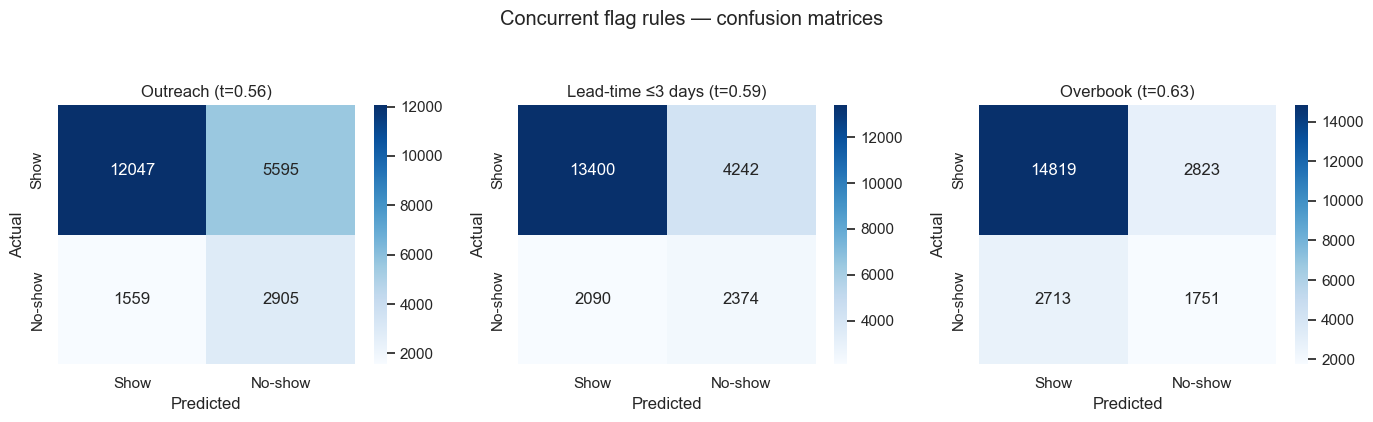

In [51]:
def clinical_summary(y_true, proba, threshold, label):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'Rule': label,
        'Threshold': round(threshold, 3),
        'Precision': round(precision_score(y_true, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, pred, zero_division=0), 4),
        'F1': round(f1_score(y_true, pred, zero_division=0), 4),
        'Flags': int(pred.sum()),
        'Caught (TP)': int(tp),
        'False alarms (FP)': int(fp),
        'Missed (FN)': int(fn),
    }

print('Rule comparison (same score, different cutoffs):')
print(pd.DataFrame([
    clinical_summary(y_test, proba, t_outreach, 'Outreach'),
    clinical_summary(y_test, proba, t_lead, 'Lead-time ≤3 days'),
    clinical_summary(y_test, proba, t_overbook, 'Overbook'),
]).to_string(index=False))

# Ranking check
tmp = risk_review.copy()
tmp['score_bin'] = pd.qcut(tmp['no_show_proba'], q=5, duplicates='drop')
print('\nNo-show rate by score quintile (should rise):')
print(tmp.groupby('score_bin', observed=True)['NoShow_actual'].agg(['size', 'mean']).round(4))

# Workload
print('\nShare of test schedule flagged:')
print(f"  Outreach : {(proba >= t_outreach).mean():.1%}")
print(f"  Lead-time: {(proba >= t_lead).mean():.1%}")
print(f"  Overbook : {(proba >= t_overbook).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, t, title in [
    (axes[0], t_outreach, 'Outreach'),
    (axes[1], t_lead, 'Lead-time ≤3 days'),
    (axes[2], t_overbook, 'Overbook'),
]:
    pred = (proba >= t).astype(int)
    sns.heatmap(
        confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Show', 'No-show'], yticklabels=['Show', 'No-show']
    )
    ax.set_title(f'{title} (t={t:.2f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Concurrent flag rules — confusion matrices', y=1.05)
plt.tight_layout()
plt.show()


Overall no-show rate: 0.202
                   Flag  n_flagged  no_show_rate_among_Yes
0  Outreach_Recommended       8500                   0.342
1  LeadTime_Limit_3Days       6616                   0.359
2  Overbook_Recommended       4574                   0.383


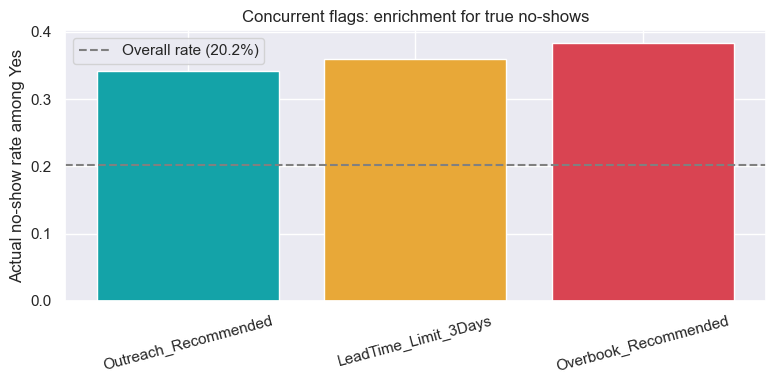

In [52]:
base_rate = risk_review['NoShow_actual'].mean()

flag_cols = ['Outreach_Recommended', 'LeadTime_Limit_3Days', 'Overbook_Recommended']
rows = []
for col in flag_cols:
    mask = risk_review[col] == 'Yes'
    rows.append({
        'Flag': col,
        'n_flagged': int(mask.sum()),
        'no_show_rate_among_Yes': risk_review.loc[mask, 'NoShow_actual'].mean() if mask.any() else None
    })

flag_qa = pd.DataFrame(rows)
print('Overall no-show rate:', round(base_rate, 3))
print(flag_qa.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(flag_qa['Flag'], flag_qa['no_show_rate_among_Yes'],
       color=['#14A3A8', '#E8A838', '#D94452'])
ax.axhline(base_rate, color='gray', linestyle='--',
           label=f'Overall rate ({base_rate:.1%})')
ax.set_ylabel('Actual no-show rate among Yes')
ax.set_title('Concurrent flags: enrichment for true no-shows')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Take-away

- Operational output = **`risk_review_concurrent_flags.csv`** with `no_show_proba` and three Yes/No flags.
- One model, one score; wider cutoff for outreach, stricter for overbook (lead-time in between or tied to overbook).
- Nesting is expected: Overbook Yes implies the milder flags are also Yes.
- Run the checks above before a pilot; validate ≤3-day booking live for access and fairness.


## Final model recommendation 

Iterations A–C established that a default 0.50 cutoff is not operationally useful and that probability cutoffs can be matched. The recommended scoring model for deployment is the F1 tuned Random Forest (Base + Risk bands).

This choice is not based on a single leaderboard metric alone:

| Factor | Why RF (Base + Risk bands) fits |
|--------|----------------------------------|
| **Performance** | F1 essentially tied with the best alternative (HistGB). It has higher precision and fewer false positives per flag |
| **Operational fit** | Concurrent flags need a score that supports both wide outreach and stricter capacity actions and lower false positive rate protects overbook decisions |
| **Interpretability** | Feature importances and risk bands are easier to explain to clinic staff than many boosted ensembles |
| **Deployment simplicity** | One model, one probability score, three documented cutoff means no separate models per action |
| **Efficiency** | Scoring 20k–100k rows is practical for batch or near-real-time clinic workflows |

**Honest comparison:** HistGB achieved a slightly higher F1 and higher recall in Iteration B. RF is preferred when the same score also drives costly actions where false positives are more expensive than a missed reminder.


## Interpretability

Clinic staff are more likely to use a system they can understand.

- **Primary driver (from exploration and modeling):** `WaitDays` shows that longer waits are associated with higher no show rates (same day 5%; 2+ weeks >30%).
- **Patient/context features:** age, clinical flags, SMS (interpreted cautiously), neighborhood **risk bands** (train-only rates grouped for stability).
- **How to explain a flag:** “This visit scored 0.64 which is above the overbook line. The largest contributors are a long wait and a higher risk area band so we recommend outreach, prefer a short lead time, and use caution on capacity.”

Feature importance from the tuned RF ,when available, should be reviewed with operations so the story stays consistent with domain knowledge.


Top features by impurity importance (F1 tuned RF):
WaitDays          0.6325
Age               0.1391
ScheduledHour     0.0644
SMS_received      0.0462
AppointmentDOW    0.0374
Gender_M          0.0148
Risk_High         0.0146
Risk_Low          0.0119
Hypertension      0.0111
Scholarship       0.0092
Diabetes          0.0067
Alcoholism        0.0062
dtype: float64


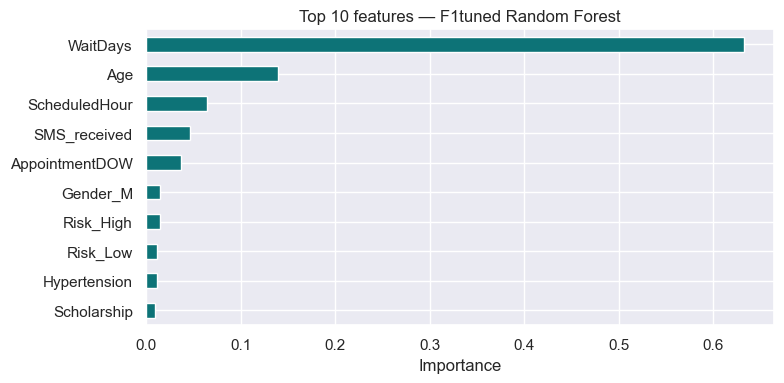

In [53]:
# Feature importance for the scoring model (interpretability)
try:
    importances = pd.Series(rf_best.feature_importances_, index=X_te_risk.columns).sort_values(ascending=False)
    print('Top features by impurity importance (F1 tuned RF):')
    print(importances.head(12).round(4))
    fig, ax = plt.subplots(figsize=(8, 4))
    importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#0D7377')
    ax.set_title('Top 10 features — F1tuned Random Forest')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Feature importance plot skipped:', e)


## Computational efficiency and deployment

| Stage | Practical approach |
|-------|--------------------|
| **Training** | Periodic batch job on historical appointments  |
| **Scoring** | Run the batch the night before or at scheduling time for output |
| **Integration** | Start with a risk review file or light scheduling add on, full implementation can follow a pilot |
| **Complexity** | One model in production not separate outreach/overbook models |
| **Compute** | RF train/score on 100k rows is modest for standard analytics environments |

**Deliverable for staff:** `risk_review_concurrent_flags.csv` showing probability plus Outreach / Lead-time / Overbook recommendations.


## Calibration

Thresholds use the ranking of `no_show_proba`. For operations, ordered risk bands matter most meaning higher scores should show higher actual no show rates.

A stricter requirement is calibration. Among visits with score ≈ 0.60, does about 60% actually no show? Random forests are often better at ranking than at perfect probability calibration.

**How we check:** score quintiles on the test set. Mean predicted score vs observed no-show rate should rise together. If the model ranks well but probabilities are shifted, thresholds can still work. For communicating “true probability” to leadership, a later calibration step can be added without changing the concurrent flag design.


Ranking / calibration check (test set):
                                  n  mean_predicted  observed_rate
band                                                              
(0.024399999999999998, 0.154]  4423          0.1104         0.0228
(0.154, 0.441]                 4420          0.2681         0.0912
(0.441, 0.553]                 4421          0.5004         0.2208
(0.553, 0.632]                 4421          0.5937         0.2911
(0.632, 0.792]                 4421          0.6842         0.3838


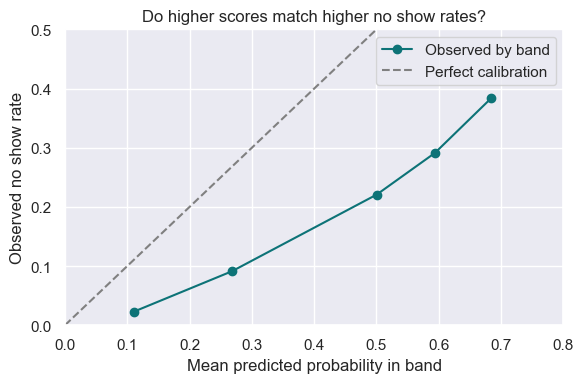

In [54]:
# Calibration-style check: observed no show rate by predicted score band
try:
    cal = pd.DataFrame({'proba': proba, 'y': y_test.values})
    cal['band'] = pd.qcut(cal['proba'], q=5, duplicates='drop')
    summary = cal.groupby('band', observed=True).agg(
        n=('y', 'size'),
        mean_predicted=('proba', 'mean'),
        observed_rate=('y', 'mean')
    ).round(4)
    print('Ranking / calibration check (test set):')
    print(summary)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(summary['mean_predicted'], summary['observed_rate'], 'o-', color='#0D7377', label='Observed by band')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability in band')
    ax.set_ylabel('Observed no show rate')
    ax.set_title('Do higher scores match higher no show rates?')
    ax.legend()
    ax.set_xlim(0, max(0.8, summary['mean_predicted'].max() + 0.05))
    ax.set_ylim(0, max(0.5, summary['observed_rate'].max() + 0.05))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Calibration check skipped:', e)


## Calibration Take Away

Score bands show a clear rising pattern. Higher predicted risk matches higher observed no show rates, so ranking is reliable for threshold based flags. Absolute probabilities are shifted upward relative to observed rates but thresholds remain valid for operations. If calibrated probabilities are needed for reporting, a calibration step can be added without changing the concurrent flag design.


## Monitoring after implementation

A deployed model should be watched, not only launched.

| Monitor | Purpose | Example trigger |
|---------|---------|-----------------|
| Precision & recall by flag | Flag quality drift | Sustained drop in precision on overbook list |
| Flag volume (% of schedule) | Staff workload | Outreach list grows beyond capacity |
| No show rate by score band | Ranking still valid? | High score band no longer elevated |
| Intervention outcomes | Did outreach help? | Requires logging actions and results |
| Data drift | Lead time mix, SMS policy, patient mix | Large shift vs training period |

**Retrain cadence:** At least quarterly or sooner if booking rules, patient mix, or no show base rate change significantly, thresholds should be re-validated after retrain. Beginning assumptions are not assumed forever.


## Dataset limitations and validation on future data

### Limitations of the current data
- **Single context:** Neighborhoods, SMS practices, and scheduling norms may not transfer to other systems or regions.
- **Observational SMS:** Higher no show rates among messaged patients were identified during data exploration, but we never determined causation.
- **No intervention outcomes:** Flags estimate risk, but they do not prove that outreach or short lead times change attendance until measured in a pilot.
- **Time snapshot:** Behavior, policies, and capacity pressures change over time.  A static split cannot capture all future shifts.
- **Unmeasured factors:** Transport, weather, work schedules, and fuller no show history may matter beyond available columns.

### How the model should be validated going forward
1. **Temporal validation:** Test on a later  time period, not only a random holdout from the same window.
2. **Pilot:** One clinic to pilot process. Compare flagged vs unflagged outcomes and workload.
3. **Threshold refresh:** Run the threshold search again when base rates or lead time distributions shift.
4. **Fairness / access check:** Monitor whether lead time limits or capacity actions disproportionately affect subgroups.
5. **Before/after metrics:** Measure no show rate, fill rate, and staff time on outreach during pilot.

These steps turn the notebook workflow into a system that can survive contact with real operations.



## Summary

No shows waste clinic capacity. Blanket reminders and fixed overbooking treat every visit as equal risk. This project ranks each appointment’s no show risk and turns that score into targeted clinical actions.

**Data:** 110,527 visits · 20.19% no-show rate. Longer waits link to higher no shows (same-day 5%, 2+ weeks >30%). Data were cleaned, stratified 80/20, and encoded with train only rules.

**Modeling path (analysis only):**
- **A:** Default models rank well (ROC-AUC 0.74) but a 0.50 cutoff almost never flags no shows.
- **B:** F1 tuned models + wider cutoff (0.56) catch many more no-shows (outreach).
- **C:** Same scores + stricter cutoff (0.63) improve precision (capacity actions).

**Production design:** One F1 tuned Random Forest (Base + Risk bands) outputs `no_show_proba`. Three thresholds on that score drive concurrent flags, Outreach ≥ 0.560, Lead-time ≥ 0.595, Overbook ≥ 0.630. Not three models, one score evaluated at three decision lines.

**Clinical application:**
- **Outreach (score ≥ 0.560):** SMS or confirmation calls wide net, low cost per false alarm.
- **Lead-time ≤ 3 days (score ≥ 0.595):** Prefer shorter booking windows for higher risk visits.
- **Overbook caution (score ≥ 0.630):** Limit capacity actions to the highest confidence list to reduce false positives.

Higher risk visits turn on more recommendations by design. Staff use one risk review file (`no_show_proba` + three Yes/No flags), not separate models.

**Why this model:** Competitive F1, higher precision than the near tied alternative, clearer features for staff, simple one model deployment. Ranking is strong but absolute probabilities run high which is acceptable for thresholds. Can calibrate later if needed for reporting.

**Limits & next steps:** Single system data and flags only estimate risk, not intervention effect. Pilot on a limited schedule, monitor precision/recall/workload and access, retrain and refresh cutoffs as conditions change.